# Ajou ECG Generalization Test (Transformer_DAE, pretrained-only)

이 노트북은 **실측 Ajou ECG(Lead II)**에 대해, 학습/파인튜닝 없이 **pretrained Transformer_DAE를 그대로 적용**했을 때의 denoise 성능을 **label-free 지표 + 시간 구간별 분포(슬라이딩 윈도우) + 최악 구간(worst-window)**으로 확인합니다.

## 실험 원리(Generalization)
- **입력**: Ajou `sgTest_*.txt`에서 Lead II를 로드(원본 267Hz).
- **전처리**: 267→360Hz polyphase resample + 파일 단위 baseline centering + resample 후 초기 1초 트림(`SPARK_TRIM_S`).
- **추론**: full-signal을 `WIN=512, HOP=256`으로 framing → 프레임별 mean/std 정규화 → 모델 추론 → 역정규화 → Hann overlap-add로 연속 신호 복원.
- **평가(정답 없음)**: raw↔deno 비교로 (1) HF-noise proxy SNR gain, (2) residual 기반 proxy, (3) HRV 변화, (4) R-peak stability(참고), (5) QRS distortion(형태 보존)을 봅니다.
- **시간 분포**: 10s/30s 슬라이딩 윈도우로 지표를 계산해 **median/IQR**과 **worst-window**를 자동 산출합니다.

## 폴더/산출물 구조
- 입력 폴더: `ajou_ecg/` (예: `sgTest_*.txt`)
- 출력 폴더: `ajou_outputs_transformer_dae/`
  - `raw_360.npy`, `deno_360.npy` (전처리 후 raw와 denoise 결과)
  - `evaluation_label_free_v2.json` (label-free 요약)
  - `evaluation_label_free_with_qrs_distortion.json` (QRS distortion 포함 요약)
  - `sliding_window_eval/`
    - `sliding_eval_windows_*.csv/.json` (윈도우별 지표 테이블)
    - `sliding_eval_summary_*.json` (median/IQR + worst-window)

**중요**: Ajou 데이터에는 clean GT가 없으므로, synthetic clean/noisy 학습/비교는 제거하고 **raw vs deno(연속)** 중심으로 봅니다.

In [2]:
# 0) (선택) TensorFlow GPU 메모리 growth 설정 (OOM 완화)
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print('✓ Enabled memory growth for GPUs:', gpus)
    except Exception as e:
        print('⚠ Could not set memory growth:', e)
else:
    print('✓ No GPU detected (CPU mode)')

2026-01-02 02:48:57.426528: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-02 02:48:57.442796: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767289737.470558 3729469 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767289737.475149 3729469 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-02 02:48:57.506584: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

✓ Enabled memory growth for GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## 0) Setup
- GPU가 있으면 메모리 growth를 켭니다(OOM 완화).
- 이후 셀에서 필요한 라이브러리를 import 합니다.

In [3]:
# 1) Imports (generalization-only notebook)
import os
import json
from math import gcd
import glob

import numpy as np
import pandas as pd
from scipy.signal import resample_poly, butter, filtfilt, find_peaks
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.optimizers import Adam

print('✓ Imports OK')

✓ Imports OK


## 1) Imports
- 신호처리(리샘플/필터/피크) + 모델(TensorFlow/Keras) + 시각화(matplotlib)만 사용합니다.

In [4]:
# 2) Configuration

# ------------------------------------------------------------
# Data source selector
# - 'ajou_sgtest' : Ajou real files: sgTest_*.txt (tab-separated multi-column)
# - 'phase_txt'   : Synthetic phase files: User01_Walk_YYMMDD.txt (single-column)
# ------------------------------------------------------------
DATA_MODE = 'phase_txt'

# Input folder
DATA_DIR = 'ajou_phase_augmented_267'

# For phase_txt mode: choose a user + phases (order will follow Stable->Breathe->Walk->Recovery)
PHASE_USER = 'User01'
PHASES = ['Stable', 'Breathe', 'Walk', 'Recovery']
PHASE_DATE = '260101'  # set to None to match any date

# Output folder (separate from Ajou real runs)
OUTPUT_DIR = 'ajou_outputs_phase_user01_260101'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Sampling rates: raw is 267Hz; model expects 360Hz
FS_SRC = 267
FS_TGT = 360
WIN = 512
HOP = 256

# 초기 1초 정도의 스파크/과도구간 제거 (resample 이후 전역 적용)
SPARK_TRIM_S = 1.0

MODEL_NAME = 'Transformer_DAE'

# --- IMPORTANT: weights와 모델 아키텍처를 정확히 일치시켜야 load_weights가 됩니다. ---
# 제공된 Transformer_DAE pretrained weights는 (num_heads=2, num_transformer_blocks=2) 설정과 일치합니다.
TD_HEAD_SIZE = 64
TD_NUM_HEADS = 2
TD_FF_DIM = 64
TD_NUM_BLOCKS = 2
TD_DROPOUT = 0

# Generalization baseline 고정: pretrained만 사용 (fine-tuned weights가 있어도 무시)
USE_FINETUNED_WEIGHTS = False

# Pretrained weights (Keras weights-only .weights.h5)
PRETRAINED_WEIGHTS = '/home/dhc99/ecg_denoise/0221_FIXED/Transformer_DAE_weights.best.weights.h5'
if not os.path.exists(PRETRAINED_WEIGHTS):
    PRETRAINED_WEIGHTS = None

LR = 1e-4

print('✓ Config:', {
    'DATA_MODE': DATA_MODE,
    'DATA_DIR': DATA_DIR,
    'PHASE_USER': PHASE_USER,
    'PHASES': PHASES,
    'PHASE_DATE': PHASE_DATE,
    'OUTPUT_DIR': OUTPUT_DIR,
    'FS_SRC': FS_SRC,
    'FS_TGT': FS_TGT,
    'WIN': WIN,
    'HOP': HOP,
    'SPARK_TRIM_S': SPARK_TRIM_S,
    'MODEL_NAME': MODEL_NAME,
    'TD_HEAD_SIZE': TD_HEAD_SIZE,
    'TD_NUM_HEADS': TD_NUM_HEADS,
    'TD_FF_DIM': TD_FF_DIM,
    'TD_NUM_BLOCKS': TD_NUM_BLOCKS,
    'TD_DROPOUT': TD_DROPOUT,
    'USE_FINETUNED_WEIGHTS': USE_FINETUNED_WEIGHTS,
    'PRETRAINED_WEIGHTS': PRETRAINED_WEIGHTS,
    'LR': LR,
})

✓ Config: {'DATA_MODE': 'phase_txt', 'DATA_DIR': 'ajou_phase_augmented_267', 'PHASE_USER': 'User01', 'PHASES': ['Stable', 'Breathe', 'Walk', 'Recovery'], 'PHASE_DATE': '260101', 'OUTPUT_DIR': 'ajou_outputs_phase_user01_260101', 'FS_SRC': 267, 'FS_TGT': 360, 'WIN': 512, 'HOP': 256, 'SPARK_TRIM_S': 1.0, 'MODEL_NAME': 'Transformer_DAE', 'TD_HEAD_SIZE': 64, 'TD_NUM_HEADS': 2, 'TD_FF_DIM': 64, 'TD_NUM_BLOCKS': 2, 'TD_DROPOUT': 0, 'USE_FINETUNED_WEIGHTS': False, 'PRETRAINED_WEIGHTS': '/home/dhc99/ecg_denoise/0221_FIXED/Transformer_DAE_weights.best.weights.h5', 'LR': 0.0001}


## Phase 데이터로 돌릴 때(방금 만든 `User01_Walk_YYMMDD.txt` 폴더)


### 재실험(입력 TXT를 다시 생성/교체한 경우) — 여기부터 실행
- **입력 데이터만 바뀐 경우(새 TXT 생성/교체)**: `3) Load ECG segments (267Hz)` 셀부터 아래로 쭉 실행
- **설정값도 바꾼 경우(DATA_MODE/DATA_DIR/PHASE_USER/PHASE_DATE/OUTPUT_DIR 등)**: `2) Configuration` 셀부터 실행
- **모델/weights까지 바꾼 경우(PRETRAINED_WEIGHTS, 모델 구조 변경)**: `2.1) Model definition (Transformer_DAE)` 셀부터 실행 (모델 재정의/가중치 재로딩 포함)


---


1) 셀 6(`Configuration`)에서 아래처럼 바꾸세요:
- `DATA_MODE = 'phase_txt'`
- `DATA_DIR = 'ajou_phase_augmented_267'`
- `PHASE_USER = 'User01'` (원하는 사용자)
- `PHASES = ['Stable','Breathe','Walk','Recovery']` 또는 `['Session']`
- (선택) `PHASE_DATE = '260101'` 처럼 날짜 고정
- (권장) `OUTPUT_DIR = 'ajou_outputs_phase_user01'` 처럼 새 폴더로 변경

2) 그 다음은 **셀 9(Load)부터 아래로 쭉 재실행**하면 됩니다(리샘플→denoise→평가→인터랙티브 뷰어).

왜 267Hz TXT가 맞냐면: 실제 실측 RAW도 267Hz이고, 노트북이 어차피 360Hz로 리샘플링해서 모델에 넣기 때문입니다.

In [5]:
# 2.1) Model definition (Transformer_DAE) + loss (self-contained)
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, Conv2DTranspose, Lambda, Multiply, BatchNormalization

def combined_ssd_mad_loss(y_true, y_pred):
    return tf.reduce_max(tf.square(y_true - y_pred), axis=-2) * 50.0 + tf.reduce_sum(tf.square(y_true - y_pred), axis=-2)

class ExpandDimsLayer(tf.keras.layers.Layer):
    def __init__(self, axis, **kwargs):
        super().__init__(**kwargs)
        self.axis = axis
    def call(self, inputs):
        return tf.expand_dims(inputs, axis=self.axis)

def Conv1DTranspose_block(input_tensor, filters, kernel_size, strides=2, activation='relu', padding='same'):
    x = ExpandDimsLayer(axis=2)(input_tensor)
    x = Conv2DTranspose(filters=filters, kernel_size=(kernel_size, 1), strides=(strides, 1), padding=padding, activation=activation)(x)
    x = Lambda(lambda t: tf.squeeze(t, axis=2))(x)
    return x

def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.0):
    x = layers.LayerNormalization(epsilon=1e-6)(inputs)
    x = layers.MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(x, x)
    x = layers.Dropout(dropout)(x)
    res = x + inputs
    x = layers.LayerNormalization(epsilon=1e-6)(res)
    x = layers.Conv1D(filters=ff_dim, kernel_size=1, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Conv1D(filters=inputs.shape[-1], kernel_size=1)(x)
    return x + res

def _get_emb(sin_inp):
    emb = tf.stack((tf.sin(sin_inp), tf.cos(sin_inp)), -1)
    emb = tf.reshape(emb, (*emb.shape[:-2], -1))
    return emb

class TFPositionalEncoding1D(tf.keras.layers.Layer):
    def __init__(self, channels: int, dtype=tf.float32):
        super().__init__()
        self.channels = int(np.ceil(channels / 2) * 2)
        self.inv_freq = np.float32(1 / np.power(10000, np.arange(0, self.channels, 2) / np.float32(self.channels)))
        self.cached_penc = None
    @tf.function
    def call(self, inputs):
        if len(inputs.shape) != 3:
            raise RuntimeError('The input tensor has to be 3d!')
        if self.cached_penc is not None and self.cached_penc.shape == inputs.shape:
            return self.cached_penc
        self.cached_penc = None
        _, x, org_channels = inputs.shape
        dtype = self.inv_freq.dtype
        pos_x = tf.range(x, dtype=dtype)
        sin_inp_x = tf.einsum('i,j->ij', pos_x, self.inv_freq)
        emb = tf.expand_dims(_get_emb(sin_inp_x), 0)
        emb = emb[0]
        self.cached_penc = tf.repeat(emb[None, :, :org_channels], tf.shape(inputs)[0], axis=0)
        return self.cached_penc

def Transformer_DAE(signal_size=512, head_size=64, num_heads=2, ff_dim=64, num_transformer_blocks=2, dropout=0.0):
    # Minimal inlined version matching the pretrained weights architecture used in this notebook.
    ks = 13
    inp = Input(shape=(signal_size, 1))
    x0 = Conv1D(filters=16, kernel_size=ks, activation='linear', strides=2, padding='same')(inp)
    x0 = layers.Activation('sigmoid')(x0)
    x0_ = Conv1D(filters=16, kernel_size=ks, activation=None, strides=2, padding='same')(inp)
    xmul0 = Multiply()([x0, x0_])
    xmul0 = BatchNormalization()(xmul0)

    x1 = Conv1D(filters=32, kernel_size=ks, activation='linear', strides=2, padding='same')(xmul0)
    x1 = layers.Activation('sigmoid')(x1)
    x1_ = Conv1D(filters=32, kernel_size=ks, activation=None, strides=2, padding='same')(xmul0)
    xmul1 = Multiply()([x1, x1_])
    xmul1 = BatchNormalization()(xmul1)

    x2 = Conv1D(filters=64, kernel_size=ks, activation='linear', strides=2, padding='same')(xmul1)
    x2 = layers.Activation('sigmoid')(x2)
    x2_ = Conv1D(filters=64, kernel_size=ks, activation='elu', strides=2, padding='same')(xmul1)
    xmul2 = Multiply()([x2, x2_])
    xmul2 = BatchNormalization()(xmul2)

    # positional + transformer blocks
    position_embed = TFPositionalEncoding1D(signal_size)
    x3 = xmul2 + position_embed(xmul2)
    for _ in range(int(num_transformer_blocks)):
        x3 = transformer_encoder(x3, head_size=head_size, num_heads=num_heads, ff_dim=ff_dim, dropout=dropout)

    x4 = x3
    x5 = Conv1DTranspose_block(x4, filters=64, kernel_size=ks, activation='elu', strides=1, padding='same')
    x5 = x5 + xmul2
    x5 = BatchNormalization()(x5)

    x6 = Conv1DTranspose_block(x5, filters=32, kernel_size=ks, activation='elu', strides=2, padding='same')
    x6 = x6 + xmul1
    x6 = BatchNormalization()(x6)

    x7 = Conv1DTranspose_block(x6, filters=16, kernel_size=ks, activation='elu', strides=2, padding='same')
    x7 = x7 + xmul0
    x8 = BatchNormalization()(x7)

    out = Conv1DTranspose_block(x8, filters=1, kernel_size=ks, activation='linear', strides=2, padding='same')
    return Model(inputs=[inp], outputs=out)

print('✓ Inlined Transformer_DAE + loss ready')

✓ Inlined Transformer_DAE + loss ready


## 2) Configuration
- **입력 선택**:
  - `DATA_MODE='ajou_sgtest'` → Ajou 실측 `sgTest_*.txt` (Lead II, 267Hz)
  - `DATA_MODE='phase_txt'` → phase 형태의 단일채널 TXT (single-column, 267Hz)
- 리샘플: 267 Hz → 360 Hz (모델 입력 호환)
- 전처리: segment baseline centering + 초기 `SPARK_TRIM_S` 트림
- 모델: Transformer_DAE (weights와 아키텍처가 반드시 일치해야 함)


### 재실험 시작점(빠른 가이드)
- **입력 파일만 바뀐 경우**: `3) Load ECG segments (267Hz)` 셀부터 실행
- **설정값 변경(DATA_MODE/USER/DATE/OUTPUT_DIR 등)**: 이 섹션 바로 아래 `Configuration` 셀부터 실행
- **weights/모델 변경(PRETRAINED_WEIGHTS 등)**: `2.1) Model definition` 셀부터 실행


Tip: phase 데이터로 돌릴 때는 `OUTPUT_DIR`도 다른 폴더로 바꿔서 결과가 섞이지 않게 하세요.

In [7]:
# 3) Load ECG segments (267Hz)
# - ajou_sgtest: sgTest_*.txt (tab-separated, multi-column) -> Lead II heuristic
# - phase_txt  : User01_Walk_YYMMDD.txt (single-column) -> direct read

import re

def _read_single_column_txt(path: str) -> np.ndarray:
    vals = []
    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.replace(',', ' ').split()
            try:
                vals.append(float(parts[0]))
            except Exception:
                continue
    if not vals:
        raise ValueError(f'No numeric samples found in {path}')
    return np.asarray(vals, dtype=float)

def load_ajou_lead2_segments(directory: str):
    files = sorted([f for f in os.listdir(directory) if f.startswith('sgTest_') and f.endswith('.txt')])
    if not files:
        raise FileNotFoundError(f'No sgTest_*.txt found under {directory}/')

    segments = []
    meta = []
    for fname in files:
        path = os.path.join(directory, fname)
        df = pd.read_csv(path, sep='\t', header=None)

        # Ajou 포맷이 두 가지로 섞일 수 있어 Lead II column을 휴리스틱으로 결정
        # - 8컬럼: [idx, Lead I, Lead II, Lead III, aVR, aVL, aVF, Temp] → Lead II = col 2
        # - 7컬럼: [Lead I, Lead II, Lead III, aVR, aVL, aVF, Temp] → Lead II = col 1
        if df.shape[1] >= 8:
            lead2_col = 2
        else:
            lead2_col = 1

        lead2 = df.iloc[:, lead2_col].astype(float).to_numpy()
        segments.append(lead2)
        meta.append({'file': fname, 'samples': int(lead2.shape[0]), 'min': float(np.nanmin(lead2)), 'max': float(np.nanmax(lead2))})

    return segments, meta

def load_phase_txt_segments(directory: str, user: str, phases: list[str], date: str | None = None):
    # Expected filename examples: User01_Walk_260101.txt, User01_Session_260101.txt
    phase_order = {
        'Stable': 0, 'Breathe': 1, 'Walk': 2, 'Move': 2, 'Recovery': 3, 'Session': 4
    }
    phases_set = set(phases)

    patt = re.compile(r'^(User\d{2})_([A-Za-z]+)_(\d{6})\.txt$')
    matches = []
    for fname in os.listdir(directory):
        if not fname.endswith('.txt'):
            continue
        m = patt.match(fname)
        if not m:
            continue
        u, ph, d = m.group(1), m.group(2), m.group(3)
        if u != user:
            continue
        if date is not None and d != date:
            continue
        if ph not in phases_set:
            continue
        matches.append((phase_order.get(ph, 99), ph, d, fname))

    if not matches:
        raise FileNotFoundError(f'No phase txt found under {directory}/ for user={user}, phases={phases}, date={date}')

    # Sort by phase order then name
    matches.sort(key=lambda t: (t[0], t[1], t[2]))

    segments = []
    meta = []
    for _, ph, d, fname in matches:
        path = os.path.join(directory, fname)
        x = _read_single_column_txt(path)
        segments.append(x)
        meta.append({'file': fname, 'phase': ph, 'date': d, 'samples': int(x.shape[0]), 'min': float(np.nanmin(x)), 'max': float(np.nanmax(x))})

    return segments, meta

# Dispatch by DATA_MODE
if DATA_MODE == 'ajou_sgtest':
    segments_267, meta = load_ajou_lead2_segments(DATA_DIR)
elif DATA_MODE == 'phase_txt':
    segments_267, meta = load_phase_txt_segments(DATA_DIR, user=PHASE_USER, phases=PHASES, date=PHASE_DATE)
else:
    raise ValueError(f'Unknown DATA_MODE={DATA_MODE}')

x_267 = np.concatenate(segments_267)
seg_lens_267 = [m['samples'] for m in meta]

print(f'✓ Loaded {len(segments_267)} file(s), total samples={len(x_267)} @ {FS_SRC}Hz')
print('  First file meta:', meta[0])
print('  Duration (s):', len(x_267)/FS_SRC)

✓ Loaded 4 file(s), total samples=160200 @ 267Hz
  First file meta: {'file': 'User01_Stable_260101.txt', 'phase': 'Stable', 'date': '260101', 'samples': 32040, 'min': -63903.32031681, 'max': -2896.73270496}
  Duration (s): 600.0


## 3) Load Ajou Data (Lead II)
- 폴더 내 `sgTest_*.txt`를 정렬 순서로 모두 읽어서 이어붙입니다.
- 파일 포맷이 7/8컬럼으로 섞일 수 있어 Lead II 컬럼을 휴리스틱으로 선택합니다.

In [8]:
# 4) Resample 267Hz → 360Hz (segment-wise) and baseline centering (per-segment)
def resample_segments(segments, fs_src, fs_tgt):
    g = gcd(fs_tgt, fs_src)
    up, down = fs_tgt // g, fs_src // g
    out = []
    out_lens = []
    for seg in segments:
        rs = resample_poly(seg, up, down)
        out.append(rs)
        out_lens.append(int(len(rs)))
    return out, out_lens

def baseline_centering_concat(x_concat, seg_lengths):
    y = x_concat.copy()
    start = 0
    for L in seg_lengths:
        end = start + L
        seg = y[start:end]
        if len(seg) >= 2:
            offset = (seg[0] + seg[-1]) / 2.0
            y[start:end] = seg - offset
        start = end
    return y

segments_360, seg_lens_360 = resample_segments(segments_267, FS_SRC, FS_TGT)
x_360 = np.concatenate(segments_360)
x_360 = baseline_centering_concat(x_360, seg_lens_360)

# --- drop initial transient/spark region globally ---
trim_n = int(max(0.0, SPARK_TRIM_S) * FS_TGT)
if trim_n > 0 and trim_n < len(x_360):
    x_360 = x_360[trim_n:]
    print(f'✓ Trimmed first {SPARK_TRIM_S:.2f}s ({trim_n} samples) to remove initial spark/artifacts')
else:
    print('✓ No initial trimming applied')

print(f'✓ Resampled total samples={len(x_360)} @ {FS_TGT}Hz')
print('  Mean/Std:', float(np.mean(x_360)), float(np.std(x_360)))

✓ Trimmed first 1.00s (360 samples) to remove initial spark/artifacts
✓ Resampled total samples=215640 @ 360Hz
  Mean/Std: -10095.737039112548 13737.29925887711


## 4) Resample + Baseline + Trim
- 각 파일(segment) 단위로 polyphase resample (`resample_poly`).
- segment별 DC/드리프트 완화를 위해 (첫 샘플 + 끝 샘플)/2 를 baseline으로 빼줍니다.
- 리샘플 후 전체 신호에서 앞 `SPARK_TRIM_S`초를 전역으로 삭제합니다.

✓ Polarity normalization (raw): {'sign': 1, 'polarity_sign': 1, 'median_qrs_at_extrema': 7766.958290363775, 'n_extrema': 176}
✓ Detected rpeaks: 599
  Detector: {'chosen_polarity': '+', 'n_pos': 626, 'n_neg': 602, 'min_rr': 108, 'used_neurokit': True}
  RR mean±std (s): 0.9981744704570791 0.3732008246195618
  HR  mean±std (bpm): 60.10973209175055 15.15807985104322


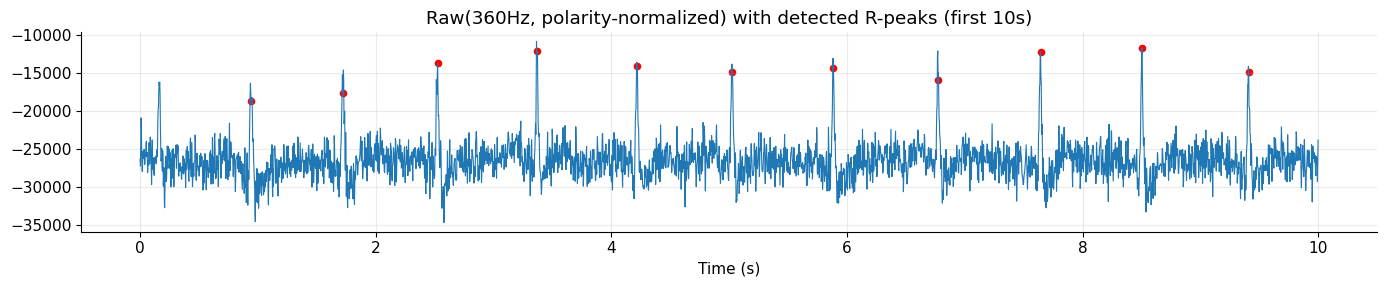

In [26]:
# 5) R-peak detection (shared; polarity-normalized => upward R-peaks)
import os, sys, importlib
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())
importlib.invalidate_caches()
import ajou_rpeak_utils as aru
importlib.reload(aru)
from ajou_rpeak_utils import normalize_ecg_polarity, detect_rpeaks

# Objective polarity normalization: QRS-band extrema median sign
x_360_pos, pol_sign, pol_info = normalize_ecg_polarity(x_360, fs=FS_TGT, min_rr_s=0.30, search_ms=80.0)
print('✓ Polarity normalization (raw):', {'sign': pol_sign, **pol_info})

rpeaks, dbg = detect_rpeaks(
    x_360_pos,
    fs=FS_TGT,
    trim_start_s=0.0,
    prefer_neurokit=True,
    prefer_positive=True,
    assume_stable_hr=True,
    min_rr_s=0.30,
    return_debug=True,
 )

print('✓ Detected rpeaks:', int(len(rpeaks)))
print('  Detector:', dbg)
if len(rpeaks) >= 2:
    rr = np.diff(rpeaks) / FS_TGT
    print('  RR mean±std (s):', float(np.mean(rr)), float(np.std(rr)))
    print('  HR  mean±std (bpm):', float(60.0/np.mean(rr)), float(np.std(60.0/rr)))

# quick plot (10s window)
secs = 10
L = min(len(x_360_pos), secs*FS_TGT)
t = np.arange(L)/FS_TGT
plt.figure(figsize=(14,3))
plt.plot(t, x_360_pos[:L], lw=0.8)
rp_vis = rpeaks[rpeaks < L]
plt.scatter(rp_vis/FS_TGT, x_360_pos[rp_vis], s=20, c='r')
plt.title('Raw(360Hz, polarity-normalized) with detected R-peaks (first 10s)')
plt.xlabel('Time (s)'); plt.tight_layout(); plt.show()

## 5) R-Peak Detection (Robust)
- bandpass + robust z-score로 전처리 후 R-peak를 검출합니다.
- **양(위쪽) 피크를 우선**하도록 후보(x vs -x)를 비교하고, QRS-band에서 *signed max*로 refine합니다.
  - (중요) refine에서 `abs()`를 쓰면 음의 피크도 R-peak로 잡힐 수 있어, 위쪽 피크 기준으로 정렬합니다.
- (선택) **심박이 일정하다는 가정** 하에 RR regularization으로 너무 가까운/비정상 peak를 제거합니다.

In [27]:
# 6) Beat extraction (minimal; used for distortion metrics / sanity checks)
def extract_beat_windows(ecg, rpeaks, win=512):
    half = win // 2
    beats = []
    valid_peaks = []
    for p in np.asarray(rpeaks, dtype=int):
        s = p - half
        e = p + half
        if s < 0 or e > len(ecg):
            continue
        beat = np.asarray(ecg[s:e], dtype=float)
        if np.any(~np.isfinite(beat)):
            continue
        if (np.max(beat) - np.min(beat)) < 1e-6:
            continue
        beats.append(beat)
        valid_peaks.append(int(p))
    beats = np.stack(beats, axis=0) if beats else np.zeros((0, win), dtype=float)
    return beats, np.asarray(valid_peaks, dtype=int)

beats_raw_win, rpeaks_valid = extract_beat_windows(x_360, rpeaks, win=WIN)
print('✓ beats_raw_win:', beats_raw_win.shape, 'valid rpeaks:', int(len(rpeaks_valid)))

✓ beats_raw_win: (599, 512) valid rpeaks: 599


## (참고) 왜 label-free 지표를 쓰나요?
Ajou 데이터는 annotation/clean ground truth가 없어서, denoise 품질을 “정답 대비 오차”로 평가하기 어렵습니다.
이 노트북은 대신 아래처럼 **전후 변화(개선 여부)**를 중심으로 봅니다.

- 고주파 잡음 감소(HF-noise proxy)
- residual 감소(residual 기반 proxy)
- 심박/HRV가 비정상적으로 망가지지 않는지(HRV)
- beat 형태(QRS)가 크게 망가지지 않는지(QRS distortion: amp/corr/lag)
- raw↔deno R-peak 검출이 안정적인지(참고용 match rate)

/home/dhc99/anaconda3/envs/ECGDENOISE/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:757: UserWarning:

Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 130 variables. 



✓ Loaded pretrained weights: /home/dhc99/ecg_denoise/0221_FIXED/Transformer_DAE_weights.best.weights.h5
✓ Saved raw/deno: ajou_outputs_phase_user01_260101


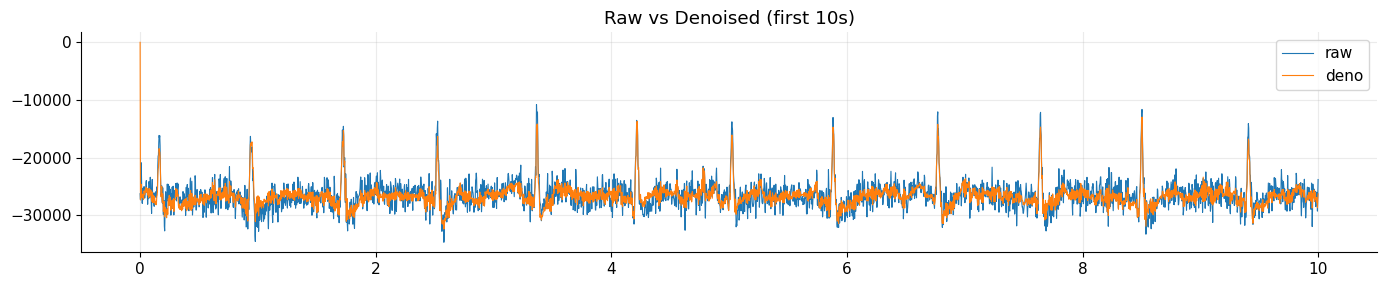

In [28]:
# 10) Denoise full signal via framing + overlap-add

# - 입력 정규화(윈도우별 mean/std) → 출력 역정규화로 스케일 보존

# NOTE: 이전 셀에서 model/weights 로드가 실패했을 수 있어, 여기서는 항상 재생성/재로드합니다.
model = None

def frame_signal(x, win=512, hop=256, pad_mode='reflect'):
    x = np.asarray(x, dtype=float)
    n = len(x)
    if n < win:
        x = np.pad(x, (0, win-n), mode=pad_mode)
    n = len(x)
    n_frames = 1 + (n - win + hop - 1) // hop
    total_needed = (n_frames - 1) * hop + win
    if total_needed > n:
        x = np.pad(x, (0, total_needed-n), mode=pad_mode)
    frames = np.stack([x[i*hop:i*hop+win] for i in range(n_frames)], axis=0)
    return frames, len(x)

def overlap_add(frames, win=512, hop=256):
    n_frames, L = frames.shape
    total_len = (n_frames - 1) * hop + win
    y = np.zeros(total_len, dtype=float)
    w = np.hanning(win)
    w = w / np.max(w)
    acc = np.zeros(total_len, dtype=float)
    for i in range(n_frames):
        s = i*hop
        y[s:s+win] += frames[i] * w
        acc[s:s+win] += w
    acc[acc == 0] = 1.0
    return y / acc

# (Re)build + load weights (must match pretrained architecture)
model = Transformer_DAE(
    signal_size=WIN,
    head_size=TD_HEAD_SIZE,
    num_heads=TD_NUM_HEADS,
    ff_dim=TD_FF_DIM,
    num_transformer_blocks=TD_NUM_BLOCKS,
    dropout=TD_DROPOUT,
 )
model.compile(loss=combined_ssd_mad_loss, optimizer=Adam(learning_rate=LR))

# Generalization baseline: pretrained only unless explicitly enabled
ft_path = os.path.join(OUTPUT_DIR, 'Transformer_DAE_ajou_finetuned.weights.h5')
if bool(globals().get('USE_FINETUNED_WEIGHTS', False)) and os.path.exists(ft_path):
    model.load_weights(ft_path)
    print('✓ Loaded fine-tuned weights:', ft_path)
elif PRETRAINED_WEIGHTS is not None and os.path.exists(PRETRAINED_WEIGHTS):
    model.load_weights(PRETRAINED_WEIGHTS)
    print('✓ Loaded pretrained weights:', PRETRAINED_WEIGHTS)
else:
    print('⚠ No weights found; using randomly initialized model')

frames, padded_len = frame_signal(x_360, WIN, HOP)
frames = frames.astype(np.float32)

# per-frame normalization (match training/inference expectation)
mu = np.mean(frames, axis=1, keepdims=True).astype(np.float32)        # (N,1)
sigma = (np.std(frames, axis=1, keepdims=True) + 1e-6).astype(np.float32) # (N,1)
X_full = ((frames - mu) / sigma)[..., None]

Y_hat = model.predict([X_full], batch_size=128, verbose=0)
Y_hat = np.squeeze(Y_hat, axis=2).astype(np.float32)  # (N,512)

# de-normalize with the same (mu, sigma); broadcast over 512 samples
Y_hat = Y_hat * sigma + mu
deno_full = overlap_add(Y_hat, WIN, HOP)

# align length to original x_360
min_len = min(len(x_360), len(deno_full))
x_360_aligned = x_360[:min_len]
deno_360 = deno_full[:min_len]

np.save(os.path.join(OUTPUT_DIR, 'raw_360.npy'), x_360_aligned)
np.save(os.path.join(OUTPUT_DIR, 'deno_360.npy'), deno_360)
print('✓ Saved raw/deno:', OUTPUT_DIR)

# quick plot (10s)
L = min(len(x_360_aligned), 10*FS_TGT)
t = np.arange(L)/FS_TGT
plt.figure(figsize=(14,3))
plt.plot(t, x_360_aligned[:L], lw=0.8, label='raw')
plt.plot(t, deno_360[:L], lw=0.8, label='deno')
plt.legend(); plt.title('Raw vs Denoised (first 10s)'); plt.tight_layout(); plt.show()

## 7) Full-signal Denoise (Framing + Overlap-Add)
- 전체 신호를 (WIN=512, HOP=256)으로 프레임 분할합니다.
- 프레임마다 mean/std로 정규화 → 모델 추론 → 같은 mean/std로 역정규화합니다.
- Hann window overlap-add로 연속 신호를 복원합니다.

In [29]:
# 11) ECG denoising evaluation (label-free friendly): polarity-normalize + detect rp_raw/rp_deno

import os, sys, importlib
import numpy as np
from scipy.signal import butter, filtfilt

if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())
importlib.invalidate_caches()
import ajou_rpeak_utils as aru
importlib.reload(aru)
from ajou_rpeak_utils import normalize_ecg_polarity, align_ecg_polarity_to_reference, detect_rpeaks

def robust_std(x):
    x = np.asarray(x, dtype=float)
    med = np.median(x)
    mad = np.median(np.abs(x - med)) + 1e-12
    return 1.4826 * mad  # ~ std for Gaussian

def _bandpass(x, fs, lo, hi, order=3):
    x = np.asarray(x, dtype=float)
    nyq = fs / 2.0
    lo = max(1e-6, float(lo))
    hi = min(nyq - 1e-6, float(hi))
    if not (0 < lo < hi < nyq):
        return x
    b, a = butter(order, [lo/nyq, hi/nyq], btype='band')
    return filtfilt(b, a, np.nan_to_num(x, nan=np.nanmean(x)))

def compute_hrv_metrics(peaks, fs):
    peaks = np.asarray(peaks, dtype=int)
    if len(peaks) < 2:
        return {'mean_rr': np.nan, 'sdnn': np.nan, 'rmssd': np.nan, 'pnn50': np.nan}
    rr = np.diff(peaks) / fs
    mean_rr = float(np.mean(rr))
    sdnn = float(np.std(rr, ddof=1)) if len(rr) > 1 else 0.0
    diffs = np.diff(rr)
    rmssd = float(np.sqrt(np.mean(diffs**2))) if len(diffs) > 0 else 0.0
    nn50 = int(np.sum(np.abs(diffs) > 0.05))
    pnn50 = float(nn50) / len(diffs) if len(diffs) > 0 else 0.0
    return {'mean_rr': mean_rr, 'sdnn': sdnn, 'rmssd': rmssd, 'pnn50': pnn50}

def ensemble_std(ecg_signal, peaks, fs, window_ms=150.0):
    half = int((window_ms / 1000.0) * fs / 2)
    templates = []
    for p in np.asarray(peaks, dtype=int):
        s = p - half
        e = p + half
        if s < 0 or e > len(ecg_signal):
            continue
        seg = ecg_signal[s:e]
        if np.any(~np.isfinite(seg)):
            continue
        templates.append(seg)
    if len(templates) < 2:
        return np.nan
    templates = np.stack(templates, axis=0)
    return float(np.mean(np.std(templates, axis=0)))

def snr_rpeak_over_hf_noise(signal, peaks, fs, qrs_band=(5.0, 20.0), noise_band=(20.0, 90.0)):
    """Proxy SNR: median(|QRSband[R]|) / robust_std(HFband(signal))."""
    signal = np.asarray(signal, dtype=float)
    peaks = np.asarray(peaks, dtype=int)
    peaks = peaks[(peaks >= 0) & (peaks < len(signal))]
    if len(peaks) == 0:
        return np.nan
    qrs = _bandpass(signal, fs, qrs_band[0], qrs_band[1])
    hf = _bandpass(signal, fs, noise_band[0], noise_band[1])
    A = float(np.median(np.abs(qrs[peaks])) + 1e-12)
    N = float(robust_std(hf) + 1e-12)
    return float(20.0 * np.log10(A / N))

# ---- Polarity handling (objective) ----
if 'FS_TGT' not in globals():
    raise RuntimeError('FS_TGT not found')
fs = float(FS_TGT)

if 'x_360_aligned' in globals():
    _raw0 = np.asarray(x_360_aligned, dtype=float)
elif 'x_360' in globals():
    _raw0 = np.asarray(x_360, dtype=float)
else:
    raise RuntimeError('raw signal not found (x_360_aligned/x_360)')

if 'deno_360' in globals():
    _den0 = np.asarray(deno_360, dtype=float)
elif 'deno_full' in globals():
    _den0 = np.asarray(deno_full, dtype=float)
else:
    raise RuntimeError('deno signal not found (deno_360/deno_full)')

_raw_pos, raw_sign, raw_info = normalize_ecg_polarity(_raw0, fs=fs, min_rr_s=0.30, search_ms=80.0)
_den_aligned, den_sign, den_info = align_ecg_polarity_to_reference(_raw_pos, _den0, fs=fs)

# expose (and keep originals) for downstream cells
if 'x_360_aligned' in globals() and 'x_360_aligned_orig' not in globals():
    x_360_aligned_orig = x_360_aligned
if 'deno_360' in globals() and 'deno_360_orig' not in globals():
    deno_360_orig = deno_360

x_360_pos_aligned = _raw_pos
deno_360_pol_aligned = _den_aligned

# overwrite the commonly-used names so later cells automatically use aligned polarity
x_360_aligned = x_360_pos_aligned
deno_360 = deno_360_pol_aligned

print('✓ Polarity normalization (raw):', {'sign': int(raw_sign), **raw_info})
print('✓ Polarity alignment (deno→raw):', {'sign': int(den_sign), **den_info})

# ---- R-peak detection (shared) ----
rp_raw, dbg_raw = detect_rpeaks(
    x_360_aligned,
    fs=fs,
    trim_start_s=0.0,
    prefer_neurokit=True,
    prefer_positive=True,
    assume_stable_hr=True,
    min_rr_s=0.30,
    return_debug=True,
 )
rp_deno, dbg_deno = detect_rpeaks(
    deno_360,
    fs=fs,
    trim_start_s=0.0,
    prefer_neurokit=True,
    prefer_positive=True,
    assume_stable_hr=True,
    min_rr_s=0.30,
    return_debug=True,
 )

print(f'✓ rp_raw={len(rp_raw)}  rp_deno={len(rp_deno)}')
print('  raw dbg :', dbg_raw)
print('  deno dbg:', dbg_deno)

snr_hf_raw_db = snr_rpeak_over_hf_noise(x_360_aligned, rp_raw, fs)
snr_hf_deno_db = snr_rpeak_over_hf_noise(deno_360, rp_deno, fs)
snr_hf_gain_db = float(snr_hf_deno_db - snr_hf_raw_db)
print('✓ HF-noise proxy SNR (dB): raw=', float(snr_hf_raw_db), 'deno=', float(snr_hf_deno_db), 'gain=', float(snr_hf_gain_db))

✓ Polarity normalization (raw): {'sign': 1, 'polarity_sign': 1, 'median_qrs_at_extrema': 7766.958290363775, 'n_extrema': 176}
✓ Polarity alignment (deno→raw): {'sign': 1, 'corr_qrs': 0.9490759890100364}
✓ rp_raw=599  rp_deno=622
  raw dbg : {'chosen_polarity': '+', 'n_pos': 626, 'n_neg': 602, 'min_rr': 108, 'used_neurokit': True}
  deno dbg: {'chosen_polarity': '-', 'n_pos': 719, 'n_neg': 672, 'min_rr': 108, 'used_neurokit': True}
✓ HF-noise proxy SNR (dB): raw= 13.746132334779018 deno= 26.791147808557973 gain= 13.045015473778955


## 8.1) QRS 진폭/형태 왜곡 정량화 (GT 없이, raw↔deno 비교)

Ajou처럼 clean/annotation이 없을 때는 “정답 대비 오차” 대신, **raw에서 검출된 R-peak를 기준으로 deno가 QRS morphology를 얼마나 보존하는지**를 봅니다.

핵심 아이디어:
- raw에서 검출된 R-peak(`rp_raw`)를 deno의 R-peak(`rp_deno`)와 **허용 오차(tol) 내에서 매칭**합니다.
- 매칭된 동일 이벤트(같은 박동)에서 QRS 주변 창(예: 300ms)을 뽑아 **진폭/폭/형태 유사도/시간지연**을 계산합니다.

지표(권장 해석):
- `amp_ratio`: (QRS-band R-peak 진폭) deno/raw  → 1에 가까울수록 진폭 보존
- `ptp_ratio`: QRS 창 내 peak-to-peak deno/raw → 1에 가까울수록 동적 범위 보존
- `width_ratio`: FWHM 유사 폭(절대값 기준) deno/raw → 1에 가까울수록 폭 보존
- `corr0`: 0-lag 상관(형태 유사도) → 1에 가까울수록 형태 보존
- `best_lag_ms`: 상관 최대가 되는 시간 이동(ms) → 0에 가까울수록 위상/타이밍 보존

일반적인 “안전 구간” 가이드(엄격한 규칙은 아님):
- 중앙값 기준 `amp_ratio`/`ptp_ratio`가 0.9–1.1 근처면 **진폭 보존 양호**
- `corr0` 중앙값이 0.95 이상이면 **형태 유사도 양호**
- `|best_lag_ms|` 중앙값이 5–10ms 이내면 **타이밍 왜곡 작음**

단, 큰 아티팩트 구간(움직임/포화 등)이 많으면 이 값들이 악화될 수 있습니다.

In [30]:
# 8.1) QRS distortion metrics (no GT): amplitude/width/correlation/lag on matched beats
import os, json
import numpy as np
from scipy.signal import butter, filtfilt

def _bandpass_local2(x, fs, lo, hi, order=3):
    x = np.asarray(x, dtype=float)
    nyq = fs / 2.0
    lo = max(1e-6, float(lo))
    hi = min(float(hi), nyq - 1e-6)
    if not (0 < lo < hi < nyq):
        return x
    b, a = butter(order, [lo/nyq, hi/nyq], btype='band')
    return filtfilt(b, a, np.nan_to_num(x, nan=np.nanmean(x)))

def _match_rpeaks_one_to_one(ref, test, fs=360, tol_ms=50):
    """Greedy one-to-one matching: for each ref peak, match nearest unused test peak within tol."""
    tol = int(round((tol_ms / 1000.0) * fs))
    ref = np.asarray(ref, dtype=int)
    test = np.asarray(test, dtype=int)
    used = np.zeros(len(test), dtype=bool)
    pairs = []
    for pr in ref:
        if len(test) == 0:
            break
        d = np.abs(test - pr)
        d[used] = 1_000_000_000
        j = int(np.argmin(d))
        if d[j] <= tol:
            used[j] = True
            pairs.append((int(pr), int(test[j]), int(test[j] - pr)))
    return pairs  # (ref_idx, test_idx, delta_samples)

def _extract_window(x, center, fs, window_ms=300.0):
    half = int(round((window_ms / 1000.0) * fs / 2.0))
    s = center - half
    e = center + half
    if s < 0 or e > len(x):
        return None
    seg = x[s:e].astype(float)
    if np.any(~np.isfinite(seg)):
        return None
    return seg

def _qrs_amplitude_features(seg, fs, qrs_band=(5.0, 20.0), search_ms=60.0):
    """Compute QRS-band amplitude & ptp in a local region around center."""
    seg = np.asarray(seg, dtype=float)
    qrs = _bandpass_local2(seg, fs, qrs_band[0], qrs_band[1])
    mid = len(qrs) // 2
    half = int(round((search_ms / 1000.0) * fs / 2.0))
    a = max(0, mid - half)
    b = min(len(qrs), mid + half + 1)
    local = qrs[a:b]
    amp = float(np.max(np.abs(local))) + 1e-12
    ptp = float(np.max(local) - np.min(local)) + 1e-12
    return amp, ptp, qrs

def _fwhm_width_ms(qrs, fs, frac=0.5):
    """FWHM-like width around center using |qrs| >= frac*peak(|qrs|)."""
    qrs = np.asarray(qrs, dtype=float)
    mid = len(qrs) // 2
    a = np.abs(qrs)
    peak = float(np.max(a)) + 1e-12
    thr = frac * peak
    # expand from center
    l = mid
    while l > 0 and a[l] >= thr:
        l -= 1
    r = mid
    while r < len(a) - 1 and a[r] >= thr:
        r += 1
    width_samples = max(1, r - l)
    return float(width_samples / fs * 1000.0)

def _corr_and_best_lag(x, y, fs, max_lag_ms=20.0):
    """Return corr at 0-lag (after z-norm) and best-lag in ms maximizing corr."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    x = x - np.mean(x)
    y = y - np.mean(y)
    sx = np.std(x) + 1e-12
    sy = np.std(y) + 1e-12
    xz = x / sx
    yz = y / sy
    corr0 = float(np.mean(xz * yz))
    max_lag = int(round((max_lag_ms / 1000.0) * fs))
    best = -1e9
    best_lag = 0
    for lag in range(-max_lag, max_lag + 1):
        if lag < 0:
            a = xz[-lag:]
            b = yz[:len(a)]
        elif lag > 0:
            a = xz[:-lag]
            b = yz[lag:lag+len(a)]
        else:
            a = xz
            b = yz
        if len(a) < 5:
            continue
        c = float(np.mean(a * b))
        if c > best:
            best = c
            best_lag = lag
    best_lag_ms = float(best_lag / fs * 1000.0)
    return corr0, float(best), best_lag_ms

# Preconditions
if 'x_360_aligned' not in globals() or 'deno_360' not in globals():
    raise RuntimeError('x_360_aligned / deno_360 not found. 먼저 Full-signal denoise를 실행하세요.')
if 'rp_raw' not in globals() or 'rp_deno' not in globals():
    raise RuntimeError('rp_raw / rp_deno not found. 먼저 Evaluation 셀을 실행하세요.')

x_raw = np.asarray(x_360_aligned, dtype=float)
x_den = np.asarray(deno_360, dtype=float)
L = min(len(x_raw), len(x_den))
x_raw = x_raw[:L]
x_den = x_den[:L]

# Use matched peaks to avoid comparing different beats
TOL_MS = 50.0
pairs = _match_rpeaks_one_to_one(rp_raw, rp_deno, fs=FS_TGT, tol_ms=TOL_MS)
print(f'✓ Matched beats: {len(pairs)} (tol={TOL_MS}ms)  / raw={len(rp_raw)} deno={len(rp_deno)}')

WINDOW_MS_QRS = 300.0
MAX_LAG_MS = 20.0
amps_raw = []
amps_den = []
ptp_raw = []
ptp_den = []
w_raw = []
w_den = []
corr0s = []
corrbests = []
lag_ms = []
deltas_ms = []

for pr, pd, delta_samp in pairs:
    seg_r = _extract_window(x_raw, pr, FS_TGT, window_ms=WINDOW_MS_QRS)
    seg_d = _extract_window(x_den, pr, FS_TGT, window_ms=WINDOW_MS_QRS)  # center on raw peak time for both
    if seg_r is None or seg_d is None:
        continue
    ar, ptr, qrs_r = _qrs_amplitude_features(seg_r, FS_TGT)
    ad, ptd, qrs_d = _qrs_amplitude_features(seg_d, FS_TGT)
    wr = _fwhm_width_ms(qrs_r, FS_TGT, frac=0.5)
    wd = _fwhm_width_ms(qrs_d, FS_TGT, frac=0.5)
    c0, cb, bl = _corr_and_best_lag(qrs_r, qrs_d, FS_TGT, max_lag_ms=MAX_LAG_MS)
    amps_raw.append(ar); amps_den.append(ad)
    ptp_raw.append(ptr); ptp_den.append(ptd)
    w_raw.append(wr); w_den.append(wd)
    corr0s.append(c0); corrbests.append(cb)
    lag_ms.append(bl)
    deltas_ms.append(float(delta_samp / FS_TGT * 1000.0))  # raw-peak vs deno-peak alignment shift (detection diff)

amps_raw = np.asarray(amps_raw, dtype=float)
amps_den = np.asarray(amps_den, dtype=float)
ptp_raw = np.asarray(ptp_raw, dtype=float)
ptp_den = np.asarray(ptp_den, dtype=float)
w_raw = np.asarray(w_raw, dtype=float)
w_den = np.asarray(w_den, dtype=float)
corr0s = np.asarray(corr0s, dtype=float)
corrbests = np.asarray(corrbests, dtype=float)
lag_ms = np.asarray(lag_ms, dtype=float)
deltas_ms = np.asarray(deltas_ms, dtype=float)

def _median_iqr(x):
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return {'median': None, 'iqr': None}
    q1 = float(np.percentile(x, 25))
    q3 = float(np.percentile(x, 75))
    return {'median': float(np.median(x)), 'iqr': float(q3 - q1)}

def _ratio_stats(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    mask = np.isfinite(a) & np.isfinite(b) & (a > 0) & (b > 0)
    r = (b[mask] / a[mask]) if np.any(mask) else np.asarray([], dtype=float)
    return r, _median_iqr(r)

amp_ratio, amp_ratio_stats = _ratio_stats(amps_raw, amps_den)
ptp_ratio, ptp_ratio_stats = _ratio_stats(ptp_raw, ptp_den)
width_ratio, width_ratio_stats = _ratio_stats(w_raw, w_den)

qrs_dist = {
    'window_ms': float(WINDOW_MS_QRS),
    'match_tol_ms': float(TOL_MS),
    'max_lag_ms': float(MAX_LAG_MS),
    'n_pairs': int(len(pairs)),
    'n_used': int(len(amp_ratio)),
    'amp_ratio': amp_ratio_stats,
    'ptp_ratio': ptp_ratio_stats,
    'width_ratio_fwhm_abs_qrs': width_ratio_stats,
    'corr0_qrs': _median_iqr(corr0s),
    'corr_best_qrs': _median_iqr(corrbests),
    'best_lag_ms_qrs': _median_iqr(lag_ms),
    'detector_peak_delta_ms(raw_to_deno)': _median_iqr(deltas_ms),
}

# Attach to main results dict if present
if 'results' in globals() and isinstance(results, dict):
    results['qrs_distortion'] = qrs_dist
    # persist updated json alongside prior eval
    out_path2 = os.path.join(OUTPUT_DIR, 'evaluation_label_free_with_qrs_distortion.json')
    with open(out_path2, 'w') as f:
        json.dump(results, f, indent=2, ensure_ascii=False)
    print('✓ Saved:', out_path2)

print('✓ QRS distortion metrics (median, IQR):')
print(json.dumps(qrs_dist, indent=2, ensure_ascii=False))

# Simple flagging (heuristic guidance)
def _flag_ratio(name, stats, lo=0.9, hi=1.1):
    m = stats.get('median', None)
    if m is None:
        return None
    return {'metric': name, 'median': m, 'ok_range': [lo, hi], 'flag': bool((m < lo) or (m > hi))}

flags = []
flags.append(_flag_ratio('amp_ratio', amp_ratio_stats, 0.9, 1.1))
flags.append(_flag_ratio('ptp_ratio', ptp_ratio_stats, 0.9, 1.1))
flags.append(_flag_ratio('width_ratio', width_ratio_stats, 0.9, 1.1))
c0_med = qrs_dist['corr0_qrs']['median']
lag_med = qrs_dist['best_lag_ms_qrs']['median']
if c0_med is not None:
    flags.append({'metric': 'corr0_qrs', 'median': float(c0_med), 'ok_min': 0.95, 'flag': bool(c0_med < 0.95)})
if lag_med is not None:
    flags.append({'metric': 'abs(best_lag_ms_qrs)', 'median': float(abs(lag_med)), 'ok_max': 10.0, 'flag': bool(abs(lag_med) > 10.0)})
flags = [f for f in flags if f is not None]
print('✓ Heuristic flags (for quick triage):')
print(json.dumps(flags, indent=2, ensure_ascii=False))

✓ Matched beats: 497 (tol=50.0ms)  / raw=599 deno=622
✓ Saved: ajou_outputs_phase_user01_260101/evaluation_label_free_with_qrs_distortion.json
✓ QRS distortion metrics (median, IQR):
{
  "window_ms": 300.0,
  "match_tol_ms": 50.0,
  "max_lag_ms": 20.0,
  "n_pairs": 497,
  "n_used": 497,
  "amp_ratio": {
    "median": 0.8646983387774319,
    "iqr": 0.14435659771718745
  },
  "ptp_ratio": {
    "median": 0.8633267008274339,
    "iqr": 0.1606483202623019
  },
  "width_ratio_fwhm_abs_qrs": {
    "median": 1.0,
    "iqr": 0.0
  },
  "corr0_qrs": {
    "median": 0.9650947794242063,
    "iqr": 0.04530927668959717
  },
  "corr_best_qrs": {
    "median": 0.9713365081069005,
    "iqr": 0.03680426562762895
  },
  "best_lag_ms_qrs": {
    "median": 0.0,
    "iqr": 2.7777777777777777
  },
  "detector_peak_delta_ms(raw_to_deno)": {
    "median": 0.0,
    "iqr": 0.0
  }
}
✓ Heuristic flags (for quick triage):
[
  {
    "metric": "amp_ratio",
    "median": 0.8646983387774319,
    "ok_range": [
      0

## 8.2) Sliding-window 평가 자동화 (Generalization Baseline, 분포 + worst-window)

목표: pretrained 모델을 **그대로** 적용했을 때, 전체 평균 1개 수치가 아니라
- 10초 / 30초 구간별로 지표를 계산하고
- 분포(median/IQR)와 worst-window(최저 성능 구간)를 자동으로 뽑아
- 결과를 JSON/CSV로 저장하고, 시각화로 한눈에 확인합니다.

포함 지표(라벨 없음 기준):
- `hf_gain_db`: HF-noise proxy SNR gain (deno - raw)
- `match_rate`: raw↔deno R-peak 매칭률(참고용)
- `qrs_amp_ratio`: matched QRS 진폭 비(deno/raw, QRS-band)
- `qrs_corr0`: matched QRS 형태 상관(0-lag)

✓ Sliding-window eval saved:
  - ajou_outputs_phase_user01_260101/sliding_window_eval/sliding_eval_windows_10_30s_step1s.csv
  - ajou_outputs_phase_user01_260101/sliding_window_eval/sliding_eval_windows_10_30s_step1s.json
  - ajou_outputs_phase_user01_260101/sliding_window_eval/sliding_eval_summary_10_30s_step1s.json


/tmp/ipykernel_3729469/156327961.py:279: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.

/tmp/ipykernel_3729469/156327961.py:279: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.

/tmp/ipykernel_3729469/156327961.py:289: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



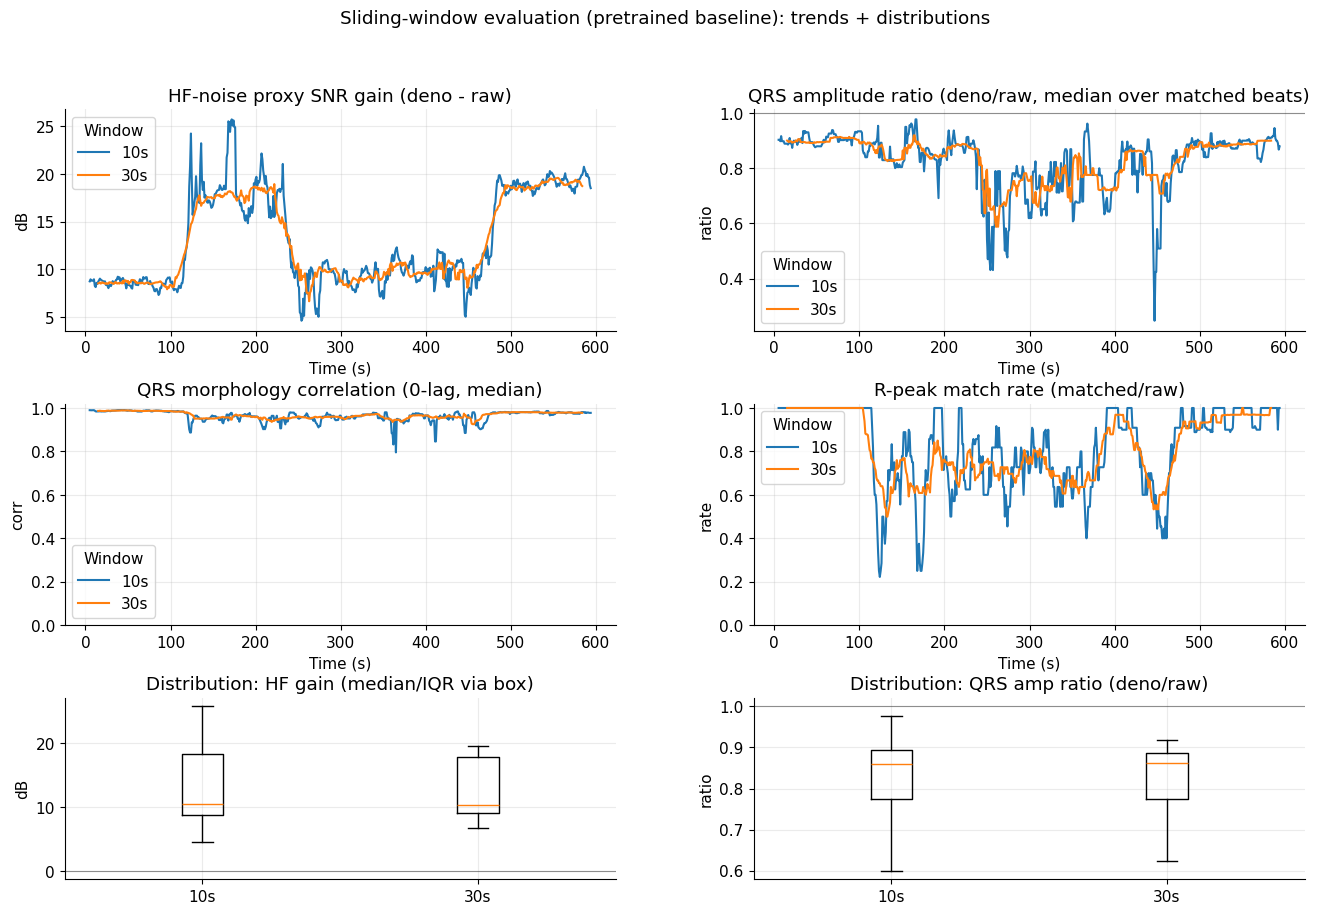

✓ Summary (median/IQR):
--- Window 10s ---
  hf_gain_db      median=10.520952741616224  IQR=9.496334767122464  min=4.611816900191796  max=25.73664682174438
  match_rate      median=0.8888888888888888  IQR=0.30000000000000004  min=0.2222222222222222  max=1.0
  qrs_amp_ratio   median=0.8603324617063747  IQR=0.11865577635530378  min=0.24708994739675025  max=0.9762814987375266
  qrs_corr0       median=0.969805120348  IQR=0.028378235707613664  min=0.7955783498630113  max=0.9903678038860059
  worst windows: {
  "hf_gain_db_min": {
    "metric": "hf_gain_db",
    "mode": "min",
    "start_s": 249.0,
    "end_s": 259.0,
    "center_s": 254.0,
    "value": 4.611816900191796,
    "n_rpeaks_raw": 11,
    "n_rpeaks_deno": 10,
    "n_pairs": 7
  },
  "qrs_corr0_min": {
    "metric": "qrs_corr0",
    "mode": "min",
    "start_s": 360.0,
    "end_s": 370.0,
    "center_s": 365.0,
    "value": 0.7955783498630113,
    "n_rpeaks_raw": 11,
    "n_rpeaks_deno": 7,
    "n_pairs": 6
  },
  "qrs_amp_ratio_mi

In [31]:
# 8.2) Sliding-window evaluation (distribution + worst-window)
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- config ----
WINDOW_SIZES_S = [10, 30]   # seconds
STEP_S = 1                 # sliding step (seconds)
TOL_MS = 50.0              # R-peak match tolerance
QRS_WINDOW_MS = 300.0      # window around R-peak for morphology metrics
QRS_BAND = (5.0, 20.0)
HF_BAND = (20.0, 90.0)
SEED = 20260101

# ---- preconditions ----
if 'x_360_aligned' not in globals() or 'deno_360' not in globals():
    raise RuntimeError('x_360_aligned / deno_360 not found. 먼저 Full-signal denoise를 실행하세요.')
if 'rp_raw' not in globals() or 'rp_deno' not in globals():
    raise RuntimeError('rp_raw / rp_deno not found. 먼저 Evaluation 셀을 실행하세요.')
if 'OUTPUT_DIR' not in globals():
    raise RuntimeError('OUTPUT_DIR not found.')
if '_bandpass' not in globals():
    raise RuntimeError('_bandpass not found. Evaluation 셀에서 bandpass 유틸을 먼저 정의/실행하세요.')

x_raw_full = np.asarray(x_360_aligned, dtype=float)
x_den_full = np.asarray(deno_360, dtype=float)
L = min(len(x_raw_full), len(x_den_full))
x_raw_full = x_raw_full[:L]
x_den_full = x_den_full[:L]
rp_r = np.asarray(rp_raw, dtype=int)
rp_d = np.asarray(rp_deno, dtype=int)
rp_r = rp_r[(rp_r >= 0) & (rp_r < L)]
rp_d = rp_d[(rp_d >= 0) & (rp_d < L)]

def robust_std(x):
    x = np.asarray(x, dtype=float)
    med = np.median(x)
    mad = np.median(np.abs(x - med)) + 1e-12
    return 1.4826 * mad

def bandpass(x, fs, lo, hi, order=3):
    # Reuse existing notebook implementation (SciPy-based) without importing SciPy here
    return _bandpass(x, fs, float(lo), float(hi), order=order)

def match_rpeaks_one_to_one(ref, test, fs, tol_ms=50.0):
    tol = int(round((tol_ms / 1000.0) * fs))
    ref = np.asarray(ref, dtype=int)
    test = np.asarray(test, dtype=int)
    used = np.zeros(len(test), dtype=bool)
    pairs = []
    for pr in ref:
        if len(test) == 0:
            break
        d = np.abs(test - pr)
        if used.any():
            d = d.copy()
            d[used] = 1_000_000_000
        j = int(np.argmin(d))
        if d[j] <= tol:
            used[j] = True
            pairs.append((int(pr), int(test[j])))
    return pairs

def snr_rpeak_over_hf_noise(signal, peaks, fs, qrs_band=(5.0, 20.0), noise_band=(20.0, 90.0)):
    signal = np.asarray(signal, dtype=float)
    peaks = np.asarray(peaks, dtype=int)
    peaks = peaks[(peaks >= 0) & (peaks < len(signal))]
    if len(peaks) == 0:
        return np.nan
    qrs = bandpass(signal, fs, qrs_band[0], qrs_band[1])
    hf = bandpass(signal, fs, noise_band[0], noise_band[1])
    A = np.median(np.abs(qrs[peaks])) + 1e-12
    N = robust_std(hf) + 1e-12
    return float(20.0 * np.log10(A / N))

def qrs_morph_metrics(raw_seg, den_seg, rp_raw_seg, rp_deno_seg, fs, tol_ms=50.0, window_ms=300.0, qrs_band=(5.0, 20.0)):
    """Return median amp_ratio and corr0 over matched beats in the segment."""
    pairs = match_rpeaks_one_to_one(rp_raw_seg, rp_deno_seg, fs, tol_ms=tol_ms)
    if len(pairs) == 0:
        return {'n_pairs': 0, 'amp_ratio_median': np.nan, 'corr0_median': np.nan}
    half = int(round((window_ms / 1000.0) * fs / 2.0))
    raw_qrs = bandpass(raw_seg, fs, qrs_band[0], qrs_band[1])
    den_qrs = bandpass(den_seg, fs, qrs_band[0], qrs_band[1])
    amp_ratios = []
    corr0s = []
    for pr, pd in pairs:
        if pr - half < 0 or pr + half > len(raw_seg):
            continue
        if pr - half < 0 or pr + half > len(den_seg):
            continue
        xr = raw_qrs[pr-half:pr+half]
        xd = den_qrs[pr-half:pr+half]  # center on raw time for both
        ar = float(np.max(np.abs(xr))) + 1e-12
        ad = float(np.max(np.abs(xd))) + 1e-12
        amp_ratios.append(ad / ar)
        # corr0 after z-norm
        xr2 = xr - np.mean(xr)
        xd2 = xd - np.mean(xd)
        sx = np.std(xr2) + 1e-12
        sy = np.std(xd2) + 1e-12
        corr0s.append(float(np.mean((xr2/sx) * (xd2/sy))))
    if len(amp_ratios) == 0:
        return {'n_pairs': 0, 'amp_ratio_median': np.nan, 'corr0_median': np.nan}
    return {
        'n_pairs': int(len(amp_ratios)),
        'amp_ratio_median': float(np.median(amp_ratios)),
        'corr0_median': float(np.median(corr0s)) if len(corr0s) else np.nan,
    }

def summarize_df(df, metric):
    x = df[metric].to_numpy(dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return {'median': None, 'iqr': None, 'min': None, 'max': None}
    q1 = float(np.percentile(x, 25))
    q3 = float(np.percentile(x, 75))
    return {'median': float(np.median(x)), 'iqr': float(q3-q1), 'min': float(np.min(x)), 'max': float(np.max(x))}

def worst_window(df, metric, mode='min'):
    if metric not in df.columns or len(df) == 0:
        return None
    tmp = df.copy()
    tmp = tmp[np.isfinite(tmp[metric])]
    if len(tmp) == 0:
        return None
    row = tmp.loc[tmp[metric].idxmin()] if mode == 'min' else tmp.loc[tmp[metric].idxmax()]
    return {
        'metric': metric,
        'mode': mode,
        'start_s': float(row['start_s']),
        'end_s': float(row['end_s']),
        'center_s': float(row['center_s']),
        'value': float(row[metric]),
        'n_rpeaks_raw': int(row.get('n_rpeaks_raw', 0)),
        'n_rpeaks_deno': int(row.get('n_rpeaks_deno', 0)),
        'n_pairs': int(row.get('n_pairs', 0)),
    }

records = []
FS = int(FS_TGT)
for W_s in WINDOW_SIZES_S:
    W = int(round(W_s * FS))
    step = int(round(STEP_S * FS))
    for start in range(0, max(0, L - W + 1), step):
        end = start + W
        raw_seg = x_raw_full[start:end]
        den_seg = x_den_full[start:end]
        rp_raw_w = rp_r[(rp_r >= start) & (rp_r < end)] - start
        rp_den_w = rp_d[(rp_d >= start) & (rp_d < end)] - start
        if len(rp_raw_w) == 0 or len(rp_den_w) == 0:
            continue
        snr_raw = snr_rpeak_over_hf_noise(raw_seg, rp_raw_w, FS, qrs_band=QRS_BAND, noise_band=HF_BAND)
        snr_den = snr_rpeak_over_hf_noise(den_seg, rp_den_w, FS, qrs_band=QRS_BAND, noise_band=HF_BAND)
        hf_gain = snr_den - snr_raw if (np.isfinite(snr_raw) and np.isfinite(snr_den)) else np.nan
        pairs = match_rpeaks_one_to_one(rp_raw_w, rp_den_w, FS, tol_ms=TOL_MS)
        match_rate = float(len(pairs) / max(1, len(rp_raw_w)))
        morph = qrs_morph_metrics(raw_seg, den_seg, rp_raw_w, rp_den_w, FS, tol_ms=TOL_MS, window_ms=QRS_WINDOW_MS, qrs_band=QRS_BAND)
        records.append({
            'window_s': float(W_s),
            'start_s': float(start / FS),
            'end_s': float(end / FS),
            'center_s': float((start + end) / 2.0 / FS),
            'n_rpeaks_raw': int(len(rp_raw_w)),
            'n_rpeaks_deno': int(len(rp_den_w)),
            'n_pairs': int(morph['n_pairs']),
            'hf_snr_raw_db': float(snr_raw) if np.isfinite(snr_raw) else np.nan,
            'hf_snr_deno_db': float(snr_den) if np.isfinite(snr_den) else np.nan,
            'hf_gain_db': float(hf_gain) if np.isfinite(hf_gain) else np.nan,
            'match_rate': float(match_rate),
            'qrs_amp_ratio': float(morph['amp_ratio_median']) if np.isfinite(morph['amp_ratio_median']) else np.nan,
            'qrs_corr0': float(morph['corr0_median']) if np.isfinite(morph['corr0_median']) else np.nan,
        })

df = pd.DataFrame.from_records(records)
if len(df) == 0:
    raise RuntimeError('No sliding-window records produced. Check peaks / signal length.')

# Save per-window CSV/JSON
out_dir = os.path.join(OUTPUT_DIR, 'sliding_window_eval')
os.makedirs(out_dir, exist_ok=True)
csv_path = os.path.join(out_dir, f'sliding_eval_windows_{"_".join(map(str,WINDOW_SIZES_S))}s_step{STEP_S}s.csv')
json_path = os.path.join(out_dir, f'sliding_eval_windows_{"_".join(map(str,WINDOW_SIZES_S))}s_step{STEP_S}s.json')
df.to_csv(csv_path, index=False)
with open(json_path, 'w') as f:
    json.dump(records, f, indent=2, ensure_ascii=False)

# Summaries
summary = {
    'baseline': {
        'model': str(MODEL_NAME) if 'MODEL_NAME' in globals() else 'unknown',
        'weights': 'fine-tuned' if bool(globals().get('USE_FINETUNED_WEIGHTS', False)) else 'pretrained',
        'use_finetuned_weights': bool(globals().get('USE_FINETUNED_WEIGHTS', False)),
        'pretrained_path': str(globals().get('PRETRAINED_WEIGHTS', None)),
    },
    'signal': {
        'fs': int(FS),
        'n_samples': int(L),
        'duration_s': float(L / FS),
    },
    'window_sizes_s': WINDOW_SIZES_S,
    'step_s': float(STEP_S),
    'metrics': {},
    'worst_windows': {},
    'paths': {'csv': csv_path, 'json': json_path},
}

metrics = ['hf_gain_db', 'match_rate', 'qrs_amp_ratio', 'qrs_corr0']
for W_s in WINDOW_SIZES_S:
    sub = df[df['window_s'] == float(W_s)].copy()
    summary['metrics'][str(W_s)] = {m: summarize_df(sub, m) for m in metrics}
    summary['worst_windows'][str(W_s)] = {
        'hf_gain_db_min': worst_window(sub, 'hf_gain_db', mode='min'),
        'qrs_corr0_min': worst_window(sub, 'qrs_corr0', mode='min'),
        'qrs_amp_ratio_min': worst_window(sub, 'qrs_amp_ratio', mode='min'),
        'match_rate_min': worst_window(sub, 'match_rate', mode='min'),
    }

summary_path = os.path.join(out_dir, f'sliding_eval_summary_{"_".join(map(str,WINDOW_SIZES_S))}s_step{STEP_S}s.json')
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print('✓ Sliding-window eval saved:')
print('  -', csv_path)
print('  -', json_path)
print('  -', summary_path)

# ---- Visualization (matplotlib, clean style) ----
plt.rcParams.update({
    'axes.grid': True,
    'grid.alpha': 0.25,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

color_map = {10.0: '#1f77b4', 30.0: '#ff7f0e'}  # blue/orange
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 2, height_ratios=[1.1, 1.1, 0.9], hspace=0.35, wspace=0.25)

# time-series plots
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

for W_s in WINDOW_SIZES_S:
    sub = df[df['window_s'] == float(W_s)].sort_values('center_s')
    c = color_map.get(float(W_s), None)
    ax1.plot(sub['center_s'], sub['hf_gain_db'], lw=1.5, label=f'{int(W_s)}s', color=c)
    ax2.plot(sub['center_s'], sub['qrs_amp_ratio'], lw=1.5, label=f'{int(W_s)}s', color=c)
    ax3.plot(sub['center_s'], sub['qrs_corr0'], lw=1.5, label=f'{int(W_s)}s', color=c)
    ax4.plot(sub['center_s'], sub['match_rate'], lw=1.5, label=f'{int(W_s)}s', color=c)

ax1.set_title('HF-noise proxy SNR gain (deno - raw)')
ax1.set_xlabel('Time (s)'); ax1.set_ylabel('dB'); ax1.legend(title='Window')
ax2.set_title('QRS amplitude ratio (deno/raw, median over matched beats)')
ax2.set_xlabel('Time (s)'); ax2.set_ylabel('ratio'); ax2.axhline(1.0, color='k', lw=0.8, alpha=0.4)
ax2.legend(title='Window')
ax3.set_title('QRS morphology correlation (0-lag, median)')
ax3.set_xlabel('Time (s)'); ax3.set_ylabel('corr'); ax3.set_ylim(0.0, 1.02)
ax3.legend(title='Window')
ax4.set_title('R-peak match rate (matched/raw)')
ax4.set_xlabel('Time (s)'); ax4.set_ylabel('rate'); ax4.set_ylim(0.0, 1.02)
ax4.legend(title='Window')

# distribution plots (boxplot)
ax5 = fig.add_subplot(gs[2, 0])
ax6 = fig.add_subplot(gs[2, 1])

def _box(ax, metric, title, ylab=None, hline=None):
    data = []
    labels = []
    for W_s in WINDOW_SIZES_S:
        sub = df[df['window_s'] == float(W_s)][metric].to_numpy(dtype=float)
        sub = sub[np.isfinite(sub)]
        data.append(sub)
        labels.append(f'{int(W_s)}s')
    ax.boxplot(data, labels=labels, showfliers=False)
    ax.set_title(title)
    ax.set_ylabel(ylab or metric)
    if hline is not None:
        ax.axhline(hline, color='k', lw=0.8, alpha=0.4)

_box(ax5, 'hf_gain_db', 'Distribution: HF gain (median/IQR via box)', ylab='dB', hline=0.0)
_box(ax6, 'qrs_amp_ratio', 'Distribution: QRS amp ratio (deno/raw)', ylab='ratio', hline=1.0)

fig.suptitle('Sliding-window evaluation (pretrained baseline): trends + distributions', y=0.98)
plt.tight_layout(); plt.show()

print('✓ Summary (median/IQR):')
for W_s in WINDOW_SIZES_S:
    key = str(W_s)
    print(f'--- Window {key}s ---')
    for m in metrics:
        s = summary['metrics'][key][m]
        print(f"  {m:14s}  median={s['median']}  IQR={s['iqr']}  min={s['min']}  max={s['max']}")
    print('  worst windows:', json.dumps(summary['worst_windows'][key], ensure_ascii=False, indent=2))

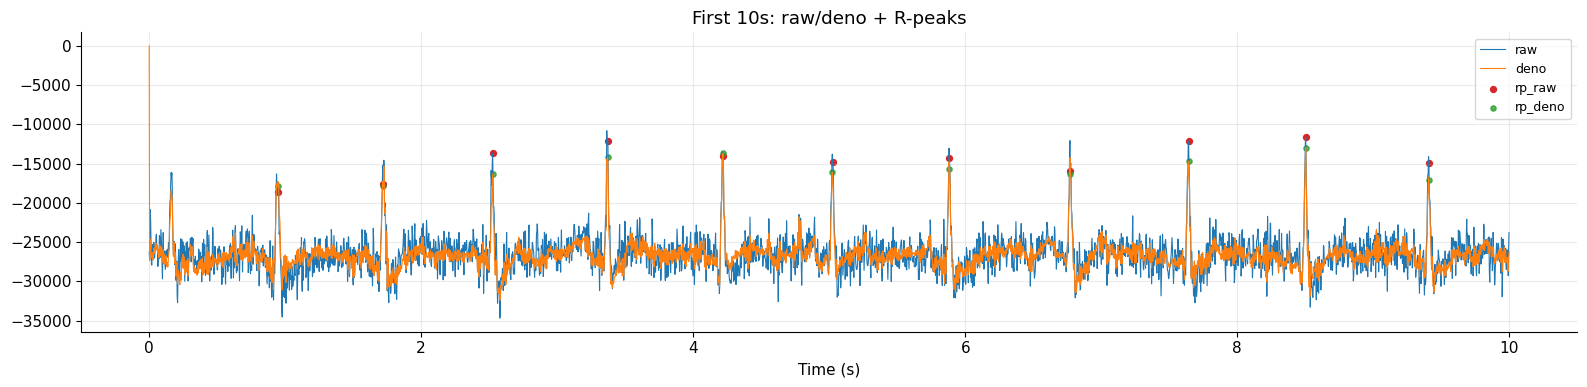

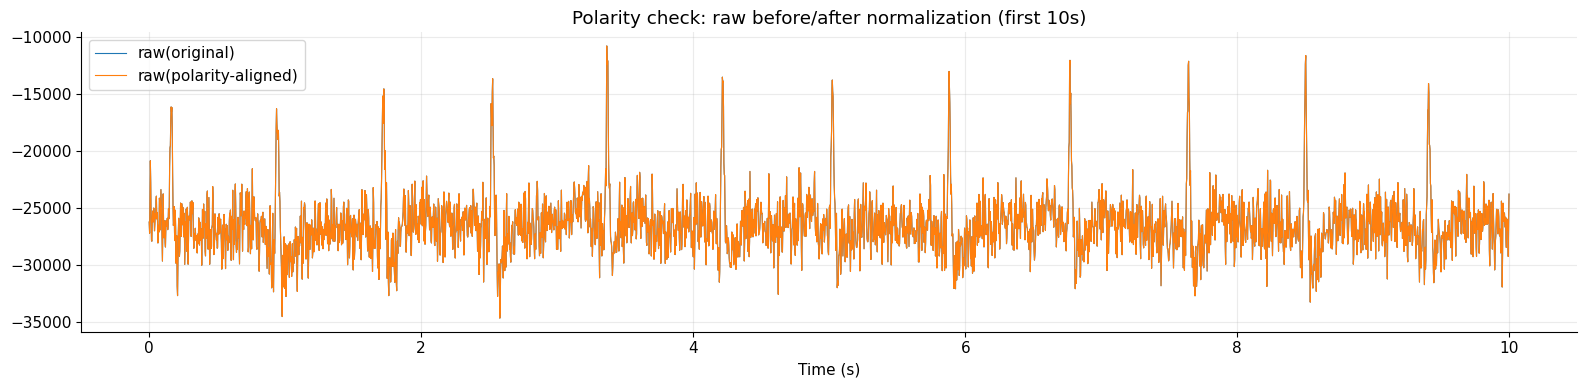

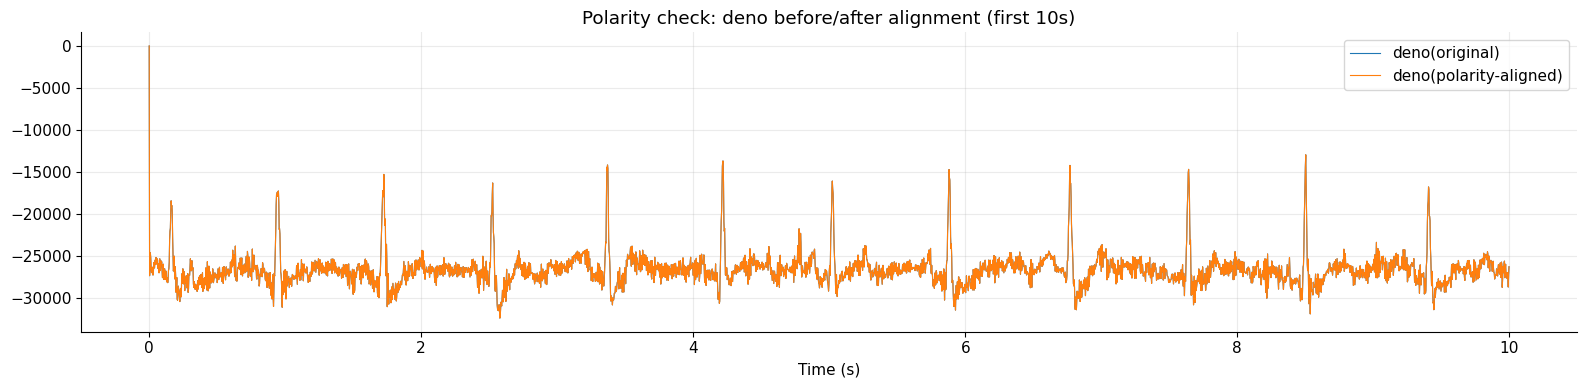

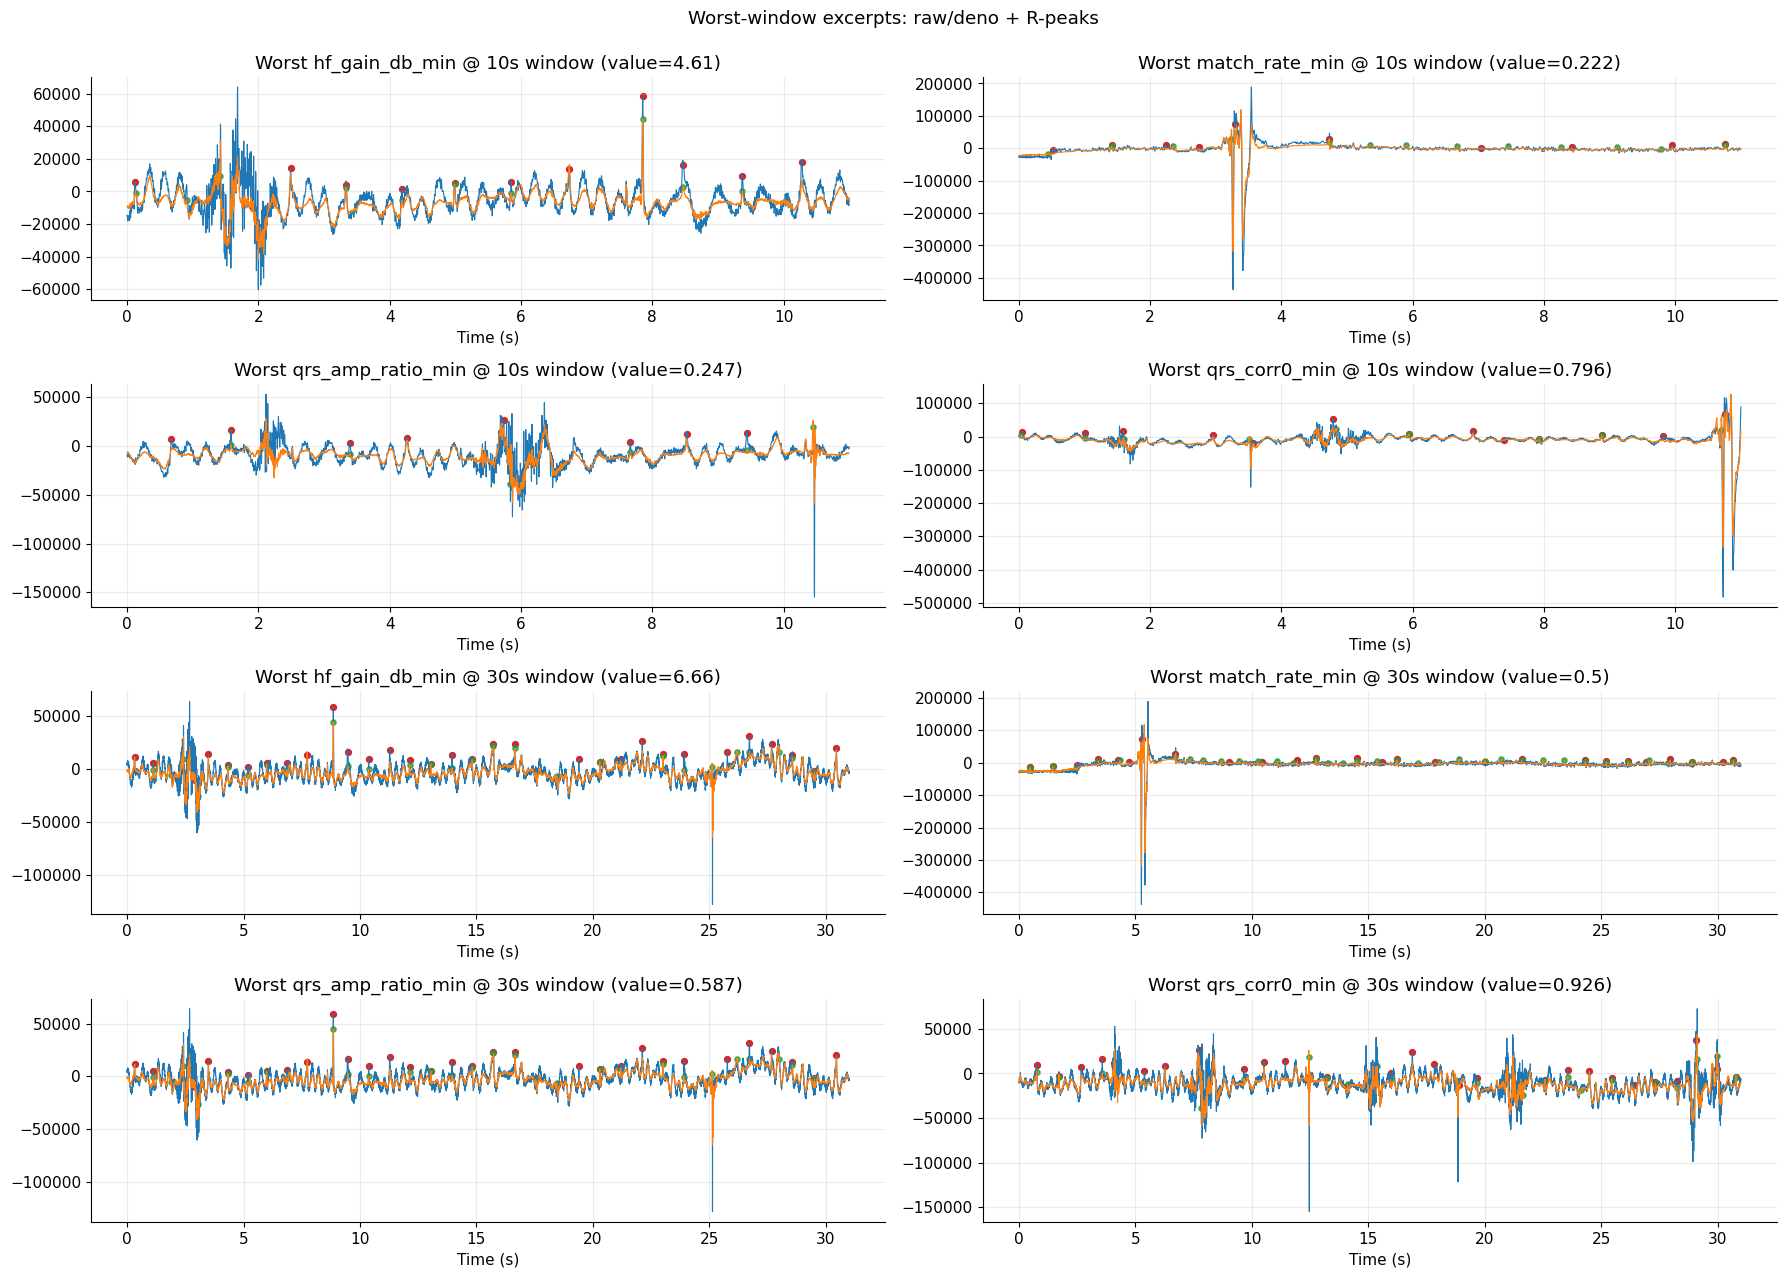

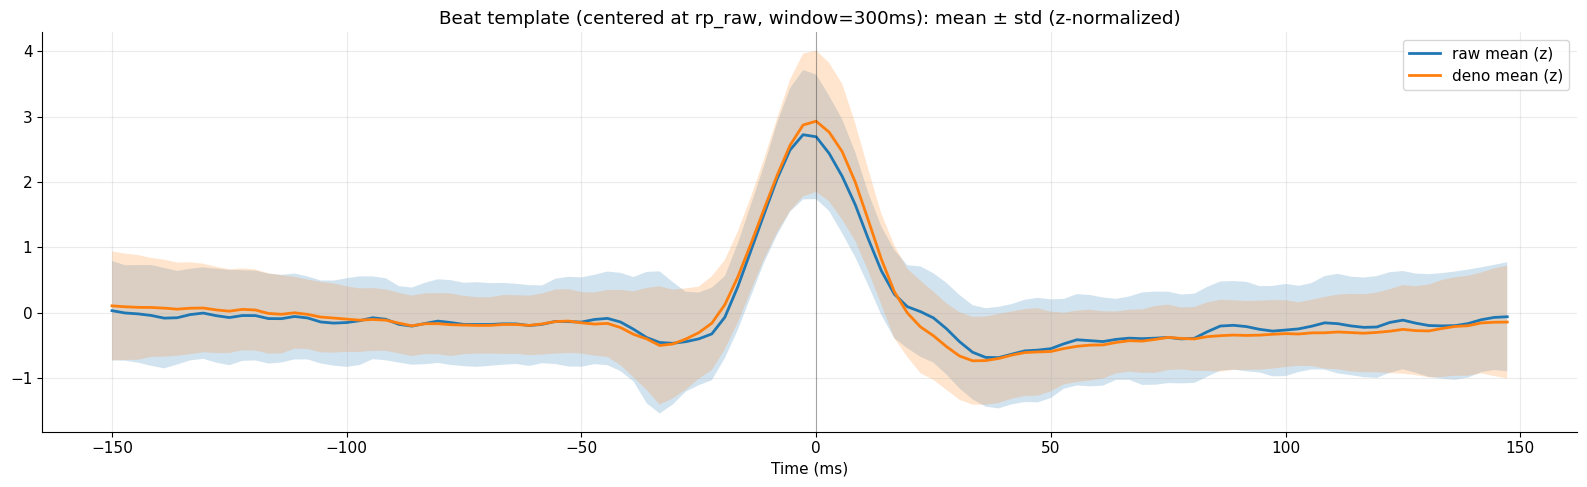

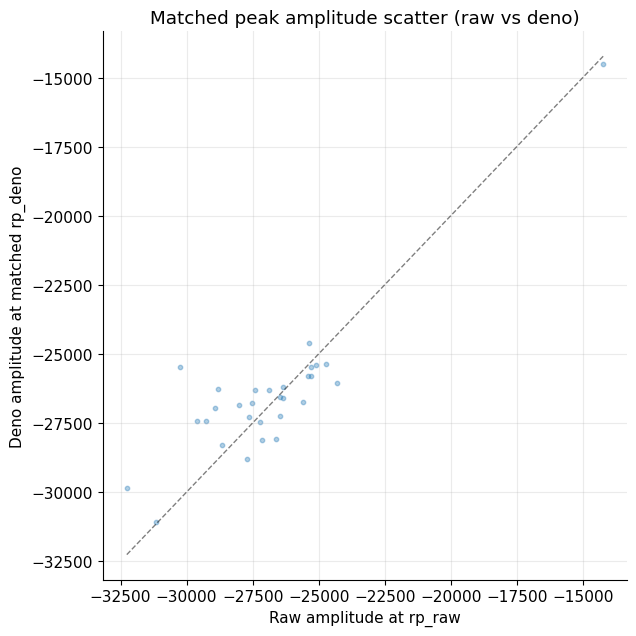

In [32]:
# 12) Visual verification: polarity + peaks + worst windows + beat templates
import numpy as np
import matplotlib.pyplot as plt
import json, os

def _require(name):
    if name not in globals():
        raise RuntimeError(f"Missing '{name}'. Run the earlier cells first.")

_require('FS_TGT')
_require('x_360_aligned')
_require('deno_360')
_require('rp_raw')
_require('rp_deno')

FS = float(FS_TGT)
raw = np.asarray(x_360_aligned, dtype=float)
den = np.asarray(deno_360, dtype=float)
rp_raw = np.asarray(rp_raw, dtype=int)
rp_deno = np.asarray(rp_deno, dtype=int)

L = min(len(raw), len(den))
raw = raw[:L]
den = den[:L]

def _plot_segment_with_peaks(ax, start_s, end_s, title, show_labels=True):
    a = int(max(0, round(start_s * FS)))
    b = int(min(L, round(end_s * FS)))
    if b - a < int(1 * FS):
        ax.set_title(title + ' (segment too short)')
        return
    t = (np.arange(a, b) - a) / FS
    ax.plot(t, raw[a:b], lw=0.8, label='raw')
    ax.plot(t, den[a:b], lw=0.8, label='deno')
    r1 = rp_raw[(rp_raw >= a) & (rp_raw < b)]
    r2 = rp_deno[(rp_deno >= a) & (rp_deno < b)]
    if len(r1):
        ax.scatter((r1 - a)/FS, raw[r1], s=18, c='tab:red', label='rp_raw')
    if len(r2):
        ax.scatter((r2 - a)/FS, den[r2], s=14, c='tab:green', label='rp_deno', alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel('Time (s)')
    if show_labels:
        ax.legend(loc='upper right', fontsize=9)

# A) Quick overview plots (first 10s): raw vs deno + peaks
plt.figure(figsize=(16, 4))
ax = plt.gca()
_plot_segment_with_peaks(ax, 0.0, 10.0, 'First 10s: raw/deno + R-peaks', show_labels=True)
plt.tight_layout(); plt.show()

# B) Polarity normalization sanity: show original vs polarity-aligned if available
if 'x_360_aligned_orig' in globals() and isinstance(x_360_aligned_orig, np.ndarray):
    raw0 = np.asarray(x_360_aligned_orig, dtype=float)[:L]
    plt.figure(figsize=(16, 4))
    t = np.arange(min(L, int(10*FS))) / FS
    plt.plot(t, raw0[:len(t)], lw=0.8, label='raw(original)')
    plt.plot(t, raw[:len(t)], lw=0.8, label='raw(polarity-aligned)')
    plt.title('Polarity check: raw before/after normalization (first 10s)')
    plt.xlabel('Time (s)'); plt.legend(); plt.tight_layout(); plt.show()

if 'deno_360_orig' in globals() and isinstance(deno_360_orig, np.ndarray):
    den0 = np.asarray(deno_360_orig, dtype=float)[:L]
    plt.figure(figsize=(16, 4))
    t = np.arange(min(L, int(10*FS))) / FS
    plt.plot(t, den0[:len(t)], lw=0.8, label='deno(original)')
    plt.plot(t, den[:len(t)], lw=0.8, label='deno(polarity-aligned)')
    plt.title('Polarity check: deno before/after alignment (first 10s)')
    plt.xlabel('Time (s)'); plt.legend(); plt.tight_layout(); plt.show()

# C) Worst-window visualizations (from sliding-window summary if available)
_summary = None
if 'summary' in globals() and isinstance(summary, dict):
    _summary = summary
elif 'summary_path' in globals() and isinstance(summary_path, str) and os.path.exists(summary_path):
    with open(summary_path, 'r') as f:
        _summary = json.load(f)

def _get_worst_segments(sumdict):
    segs = []
    if not sumdict:
        return segs
    ww = sumdict.get('worst_windows', {})
    for W_s, d in ww.items():
        if not isinstance(d, dict):
            continue
        for k in ['hf_gain_db_min', 'qrs_corr0_min', 'qrs_amp_ratio_min', 'match_rate_min']:
            v = d.get(k)
            if not isinstance(v, dict):
                continue
            segs.append({
                'window_s': float(W_s),
                'key': k,
                'start_s': float(v.get('start_s', 0.0)),
                'end_s': float(v.get('end_s', 0.0)),
                'value': float(v.get('value', np.nan)),
            })
    # de-dup by (window_s,key) and sort by window then key
    seen = set()
    out = []
    for s in segs:
        kk = (s['window_s'], s['key'])
        if kk in seen:
            continue
        seen.add(kk)
        out.append(s)
    out.sort(key=lambda z: (z['window_s'], z['key']))
    return out

worst_segs = _get_worst_segments(_summary)
if len(worst_segs) == 0:
    print('⚠ No sliding-window summary found; skipping worst-window plots')
else:
    n = len(worst_segs)
    ncols = 2
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 3.2*nrows), squeeze=False)
    for i, s in enumerate(worst_segs):
        r = i // ncols
        c = i % ncols
        ax = axes[r][c]
        st = max(0.0, s['start_s'])
        en = min(float(L/FS), s['end_s'])
        # add a tiny margin for context
        pad = 0.5
        st2 = max(0.0, st - pad)
        en2 = min(float(L/FS), en + pad)
        title = f"Worst {s['key']} @ {int(s['window_s'])}s window (value={s['value']:.3g})"
        _plot_segment_with_peaks(ax, st2, en2, title, show_labels=False)
    # hide empty axes
    for j in range(n, nrows*ncols):
        axes[j//ncols][j%ncols].axis('off')
    fig.suptitle('Worst-window excerpts: raw/deno + R-peaks', y=0.995)
    plt.tight_layout(); plt.show()

# D) Beat template sanity (aligned at rp_raw, compare raw vs deno)
def _extract_templates(sig, peaks, fs, window_ms=300.0, max_beats=120):
    half = int(round((window_ms/1000.0) * fs / 2.0))
    peaks = np.asarray(peaks, dtype=int)
    peaks = peaks[(peaks >= half) & (peaks < len(sig) - half)]
    if len(peaks) == 0:
        return None
    if len(peaks) > max_beats:
        # deterministic subsample
        idx = np.linspace(0, len(peaks)-1, max_beats).astype(int)
        peaks = peaks[idx]
    X = np.stack([sig[p-half:p+half] for p in peaks], axis=0)
    return X

win_ms = float(globals().get('WINDOW_MS_QRS', 300.0))
Xr = _extract_templates(raw, rp_raw, FS, window_ms=win_ms)
Xd = _extract_templates(den, rp_raw, FS, window_ms=win_ms)  # center on raw peaks
if Xr is None or Xd is None:
    print('⚠ Not enough beats for template plot')
else:
    # z-normalize per beat for shape-only comparison
    Xr2 = Xr - np.mean(Xr, axis=1, keepdims=True)
    Xd2 = Xd - np.mean(Xd, axis=1, keepdims=True)
    Xr2 = Xr2 / (np.std(Xr2, axis=1, keepdims=True) + 1e-12)
    Xd2 = Xd2 / (np.std(Xd2, axis=1, keepdims=True) + 1e-12)
    mr = np.mean(Xr2, axis=0)
    sr = np.std(Xr2, axis=0)
    md = np.mean(Xd2, axis=0)
    sd = np.std(Xd2, axis=0)
    t = (np.arange(Xr2.shape[1]) - Xr2.shape[1]//2) / FS * 1000.0
    plt.figure(figsize=(16, 5))
    plt.plot(t, mr, lw=2.0, label='raw mean (z)')
    plt.fill_between(t, mr-sr, mr+sr, alpha=0.2)
    plt.plot(t, md, lw=2.0, label='deno mean (z)')
    plt.fill_between(t, md-sd, md+sd, alpha=0.2)
    plt.axvline(0.0, color='k', lw=0.8, alpha=0.3)
    plt.title(f'Beat template (centered at rp_raw, window={win_ms:.0f}ms): mean ± std (z-normalized)')
    plt.xlabel('Time (ms)'); plt.legend(); plt.tight_layout(); plt.show()

# E) Peak amplitude scatter (raw peak vs deno peak at matched events)
if 'pairs' in globals() and isinstance(pairs, (list, tuple)) and len(pairs) > 0:
    prs = np.array([p[0] for p in pairs], dtype=int)
    pds = np.array([p[1] for p in pairs], dtype=int)
    mask = (prs >= 0) & (prs < L) & (pds >= 0) & (pds < L)
    prs = prs[mask]; pds = pds[mask]
    if len(prs) > 0:
        plt.figure(figsize=(6.5, 6.5))
        plt.scatter(raw[prs], den[pds], s=10, alpha=0.35)
        mn = float(min(np.min(raw[prs]), np.min(den[pds])))
        mx = float(max(np.max(raw[prs]), np.max(den[pds])))
        plt.plot([mn, mx], [mn, mx], 'k--', lw=1, alpha=0.5)
        plt.xlabel('Raw amplitude at rp_raw')
        plt.ylabel('Deno amplitude at matched rp_deno')
        plt.title('Matched peak amplitude scatter (raw vs deno)')
        plt.tight_layout(); plt.show()

## 8) Evaluation (Label-free)
Ajou 데이터에는 annotation/clean GT가 없기 때문에, 아래 지표들은 **절대적인 정답 기반 성능**이 아니라 **전후 변화(개선 여부) 참고용**입니다.

- Proxy SNR: R-peak(QRS-band) 크기 대비 HF-noise 크기
- Residual SNR: residual(raw-deno)의 QRS-band 잡음 크기
- HRV: RR mean/SDNN/RMSSD/pNN50 (과평활/왜곡 여부 체크)
- Ensemble STD: R-peak 정렬 후 형태 변동성(표준편차)
- R-peak stability: raw↔deno 검출 매칭률(참고용)
- QRS distortion: amp ratio / corr0 / best-lag 등(형태 보존)

## (중요) 구간별 INTERACTIVE 뷰어
아래 코드셀(다음 셀)은 **raw vs deno(그리고 residual)**를 **구간별로 인터랙티브하게** 확인하기 위한 뷰어입니다.

사용법:
- 위쪽 셀들을 실행해서 `x_360_aligned`, `deno_360`, `rp_raw`, `rp_deno`가 만들어진 상태에서 실행
- `Start(s)`로 시작 시점을 이동, `Window(s)`로 10/30초 선택
- `Jump`에서 worst-window(예: `worst hf_gain_db`)를 고르고 `Go`를 누르면 해당 구간으로 이동
- 하단에 선택 구간의 sliding-window 지표(가장 가까운 행)를 같이 출력합니다.

In [ ]:
# 12) Interactive visualization: segment-by-segment (raw vs deno) + metrics lookup
import os, glob, json
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import ipywidgets as widgets
from IPython.display import display, clear_output

# Safety checks
if 'x_360_aligned' not in globals() or 'deno_360' not in globals():
    raise RuntimeError('x_360_aligned / deno_360 not found. 먼저 Full-signal denoise를 실행하세요.')
if 'rp_raw' not in globals() or 'rp_deno' not in globals():
    raise RuntimeError('rp_raw / rp_deno not found. 먼저 Evaluation 셀을 실행하세요.')
if 'OUTPUT_DIR' not in globals():
    raise RuntimeError('OUTPUT_DIR not found.')

x_raw = np.asarray(x_360_aligned, dtype=float)
x_deno = np.asarray(deno_360, dtype=float)
L = min(len(x_raw), len(x_deno))
x_raw = x_raw[:L]
x_deno = x_deno[:L]
fs = int(FS_TGT)
dur_s = L / fs
rp_raw_arr = np.asarray(rp_raw, dtype=int)
rp_deno_arr = np.asarray(rp_deno, dtype=int)
rp_raw_arr = rp_raw_arr[(rp_raw_arr >= 0) & (rp_raw_arr < L)]
rp_deno_arr = rp_deno_arr[(rp_deno_arr >= 0) & (rp_deno_arr < L)]

# Load sliding-window table if present (for metric lookup + worst-window jump)
df_sw = None
sw_dir = os.path.join(OUTPUT_DIR, 'sliding_window_eval')
if os.path.isdir(sw_dir):
    csvs = sorted(glob.glob(os.path.join(sw_dir, 'sliding_eval_windows_*_step*.csv')))
    if csvs:
        df_sw = pd.read_csv(csvs[-1])

summary_sw = None
if os.path.isdir(sw_dir):
    sums = sorted(glob.glob(os.path.join(sw_dir, 'sliding_eval_summary_*_step*.json')))
    if sums:
        with open(sums[-1], 'r') as f:
            summary_sw = json.load(f)

def _nearest_metrics(df, window_s, start_s):
    if df is None or len(df) == 0:
        return None
    sub = df[df['window_s'] == float(window_s)].copy()
    if len(sub) == 0:
        return None
    # choose nearest start_s
    sub['d'] = np.abs(sub['start_s'].to_numpy(dtype=float) - float(start_s))
    row = sub.iloc[int(np.argmin(sub['d'].to_numpy()))]
    out = {k: (None if (k not in row or not np.isfinite(row[k])) else float(row[k])) for k in [
        'hf_gain_db','match_rate','qrs_amp_ratio','qrs_corr0','n_pairs','n_rpeaks_raw','n_rpeaks_deno'
    ]}
    out['start_s'] = float(row['start_s']); out['end_s'] = float(row['end_s'])
    return out

def _segment_plot(start_s, window_s, show_peaks=True):
    start = int(round(float(start_s) * fs))
    win = int(round(float(window_s) * fs))
    start = max(0, min(start, max(0, L - win)))
    end = min(L, start + win)
    t = np.arange(start, end) / fs
    raw_seg = x_raw[start:end]
    den_seg = x_deno[start:end]
    resid = raw_seg - den_seg

    fig = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.08, row_heights=[0.65, 0.35])
    fig.add_trace(go.Scatter(x=t, y=raw_seg, name='raw', mode='lines', line=dict(width=1)), row=1, col=1)
    fig.add_trace(go.Scatter(x=t, y=den_seg, name='deno', mode='lines', line=dict(width=1)), row=1, col=1)
    fig.add_trace(go.Scatter(x=t, y=resid, name='residual (raw-deno)', mode='lines', line=dict(width=1, color='black')), row=2, col=1)

    if show_peaks:
        pr = rp_raw_arr[(rp_raw_arr >= start) & (rp_raw_arr < end)]
        pdn = rp_deno_arr[(rp_deno_arr >= start) & (rp_deno_arr < end)]
        if len(pr) > 0:
            fig.add_trace(go.Scatter(
                x=pr / fs, y=x_raw[pr], name='R-peaks(raw)', mode='markers',
                marker=dict(size=6, color='red', symbol='circle')
            ), row=1, col=1)
        if len(pdn) > 0:
            fig.add_trace(go.Scatter(
                x=pdn / fs, y=x_deno[pdn], name='R-peaks(deno)', mode='markers',
                marker=dict(size=6, color='orange', symbol='x')
            ), row=1, col=1)

    fig.update_layout(
        height=520,
        margin=dict(l=40, r=20, t=50, b=40),
        legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='left', x=0),
        template='plotly_white',
        title=f'Segment view: start={start/fs:.2f}s, window={window_s}s'
    )
    fig.update_xaxes(title_text='Time (s)', row=2, col=1)
    fig.update_yaxes(title_text='Amplitude', row=1, col=1)
    fig.update_yaxes(title_text='Residual', row=2, col=1)
    return fig, start/fs, end/fs

# Widgets
window_dd = widgets.Dropdown(options=[10, 30], value=10, description='Window(s):')
start_sl = widgets.FloatSlider(value=0.0, min=0.0, max=max(0.0, dur_s - float(window_dd.value)), step=1.0, description='Start(s):', readout_format='.0f', continuous_update=False)
show_peaks_cb = widgets.Checkbox(value=True, description='Show R-peaks')

jump_dd = widgets.Dropdown(options=[('—', 'none'), ('worst hf_gain_db', 'hf_gain_db_min'), ('worst qrs_corr0', 'qrs_corr0_min'), ('worst qrs_amp_ratio', 'qrs_amp_ratio_min'), ('worst match_rate', 'match_rate_min')], value='none', description='Jump:')
jump_btn = widgets.Button(description='Go', button_style='')

out = widgets.Output()

def _update_slider_range(*_):
    w = float(window_dd.value)
    start_sl.max = max(0.0, dur_s - w)
    if start_sl.value > start_sl.max:
        start_sl.value = start_sl.max

def _do_jump(_):
    if summary_sw is None or df_sw is None:
        return
    sel = jump_dd.value
    if sel == 'none':
        return
    key = str(float(window_dd.value))
    ww = summary_sw.get('worst_windows', {}).get(key, {}).get(sel, None)
    if ww is None:
        return
    start_sl.value = float(ww['start_s'])

def _render(*_):
    with out:
        clear_output(wait=True)
        fig, a_s, b_s = _segment_plot(start_sl.value, window_dd.value, show_peaks=show_peaks_cb.value)
        display(fig)
        m = _nearest_metrics(df_sw, window_dd.value, start_sl.value)
        if m is not None:
            print('Metrics (nearest sliding-window row):')
            print(json.dumps(m, ensure_ascii=False, indent=2))
        else:
            print('Metrics lookup: sliding_window_eval CSV not found yet.')

window_dd.observe(_update_slider_range, names='value')
window_dd.observe(_render, names='value')
start_sl.observe(_render, names='value')
show_peaks_cb.observe(_render, names='value')
jump_btn.on_click(_do_jump)
jump_btn.on_click(_render)

_update_slider_range()
controls = widgets.HBox([window_dd, start_sl, show_peaks_cb, jump_dd, jump_btn])
display(controls, out)
_render()

Output()